<a href="https://colab.research.google.com/github/akaul98/Biking-Demand-prediction/blob/master/yahoo_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement: Prediction of Stock Price 

In [ ]:
'''Step 0)  Analysis of data
   Step 1)  Reading of data,Importing header files,making a copy
   Step 2)  Prelimary analysis of data dropping of obvious feature
                i) Ids and other non important features
   Step 3)  Dealing with null values
                i)  If the number of null values is more than 50% Drop that columns
                ii) If null value is int/float fill the data by mean of that columns
                iii)If null value is object/category fill the data by mode of that columns
                iv) Convert the data into its appropriate data types
   Step 4)  Visualise the data
                i)This helps in seeing the correlation of data so we can drop the fields which are highly correlated
                ii)How clean is our data
   Step 5)  Check for regression assumptions
                i)normality
                ii)autocorrealtion
                iii)correaltions
                iv)outliers 
   Step 6)  Drop irrelevant features
   Step 7)  Create/ modify features
   Step 8)  Feature engineering
   Step 9)  Create dummy variables(For categorical features)
   Step 10)  Train and test Split()
   Step 11) Fit and score the model
                i)Model Cross Validation
                ii)HyperparameterTuning 
   Step 12) Present the results'''

'Step 0)  Analysis of data\n   Step 1)  Reading of data,Importing header files,making a copy\n   Step 2)  Prelimary analysis of data dropping of obvious feature\n                i) Ids and other non important features\n   Step 3)  Dealing with null values\n                i)  If the number of null values is more than 50% Drop that columns\n                ii) If null value is int/float fill the data by mean of that columns\n                iii)If null value is object/category fill the data by mode of that columns\n                iv) Convert the data into its appropriate data types\n   Step 4)  Visualise the data\n                i)This helps in seeing the correlation of data so we can drop the fields which are highly correlated\n                ii)How clean is our data\n   Step 5)  Check for regression assumptions\n                i)normality\n                ii)autocorrealtion\n                iii)correaltions\n                iv)outliers \n   Step 6)  Drop irrelevant features\n   St

Step 1) Reading of data And Importing header files|

In [ ]:
#importing all the imporant header file
import pandas as pd
import pandas_datareader as pdr
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import minmax_scale
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from pylab import *
plt.style.use('fivethirtyeight')
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima_model import ARIMA
from datetime import date
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
today = date.today()

start="2005-12-07"
end=today.strftime("%Y-%m-%d")
end

'2020-11-16'

In [ ]:
df=pdr.get_data_yahoo("YESBANK.NS",start=start,end=end)
df

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2005-12-07,14.15,14.00,14.04,14.05,975450.0,9.017356
2005-12-08,14.28,14.05,14.16,14.18,1368365.0,9.100791
2005-12-09,14.34,14.17,14.29,14.20,1369180.0,9.113628
2005-12-12,14.32,13.82,14.22,13.96,1313620.0,8.959593
2005-12-13,14.15,13.83,13.98,14.02,1556415.0,8.998102
...,...,...,...,...,...,...
2020-11-09,12.90,12.25,12.35,12.90,128615608.0,12.900000
2020-11-10,13.50,13.50,13.50,13.50,80270780.0,13.500000
2020-11-11,14.15,14.15,14.15,14.15,54007188.0,14.150000


In [ ]:
#Creating a copy of the dataset so that no data is lost
data=df.copy()
data

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2005-12-07,14.15,14.00,14.04,14.05,975450.0,9.017356
2005-12-08,14.28,14.05,14.16,14.18,1368365.0,9.100791
2005-12-09,14.34,14.17,14.29,14.20,1369180.0,9.113628
2005-12-12,14.32,13.82,14.22,13.96,1313620.0,8.959593
2005-12-13,14.15,13.83,13.98,14.02,1556415.0,8.998102
...,...,...,...,...,...,...
2020-11-09,12.90,12.25,12.35,12.90,128615608.0,12.900000
2020-11-10,13.50,13.50,13.50,13.50,80270780.0,13.500000
2020-11-11,14.15,14.15,14.15,14.15,54007188.0,14.150000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3676 entries, 2005-12-07 to 2020-11-13
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       3676 non-null   float64
 1   Low        3676 non-null   float64
 2   Open       3676 non-null   float64
 3   Close      3676 non-null   float64
 4   Volume     3676 non-null   float64
 5   Adj Close  3676 non-null   float64
dtypes: float64(6)
memory usage: 201.0 KB


In [ ]:
data.describe()

,High,Low,Open,Close,Volume,Adj Close
count,3676.000000,3676.000000,3676.000000,3676.000000,3.676000e+03,3676.000000
mean,110.701382,106.791208,108.882495,108.671529,3.024327e+07,94.830798
std,100.415235,97.865874,99.252854,99.084700,6.740983e+07,98.017969
min,8.600000,5.650000,8.600000,8.320000,0.000000e+00,5.339815
25%,35.734999,33.835000,34.815000,34.737501,6.381678e+06,24.714294
50%,67.285000,64.630001,66.020000,65.875000,1.142739e+07,47.667681
75%,160.690006,156.117496,158.200001,158.525002,2.130303e+07,136.838474
max,404.000000,392.549988,396.799988,394.000000,1.057367e+09,383.467163


In [ ]:
data.index

DatetimeIndex(['2005-12-07', '2005-12-08', '2005-12-09', '2005-12-12',
               '2005-12-13', '2005-12-14', '2005-12-15', '2005-12-16',
               '2005-12-19', '2005-12-20',
               ...
               '2020-11-02', '2020-11-03', '2020-11-04', '2020-11-05',
               '2020-11-06', '2020-11-09', '2020-11-10', '2020-11-11',
               '2020-11-12', '2020-11-13'],
              dtype='datetime64[ns]', name='Date', length=3676, freq=None)

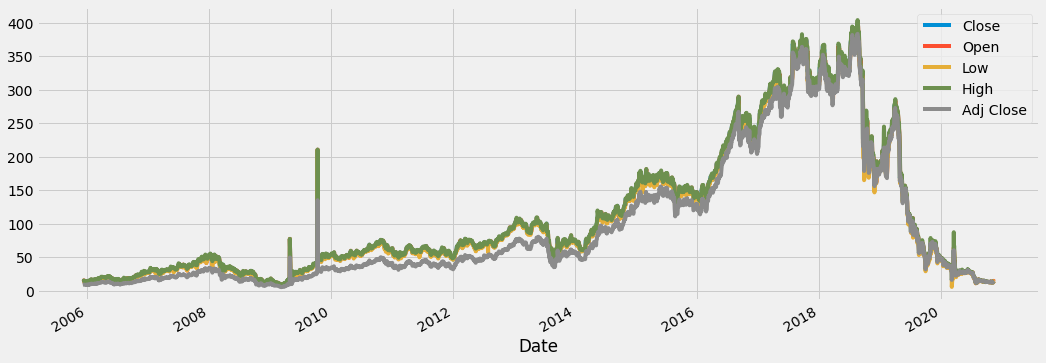

In [ ]:
data[["Close","Open","Low","High","Adj Close"]].plot(figsize=(16,6))

In [ ]:
df.corr()#is used to find the corealtion

,High,Low,Open,Close,Volume,Adj Close
High,1.000000,0.999407,0.999690,0.999666,-0.087016,0.997182
Low,0.999407,1.000000,0.999557,0.999738,-0.099423,0.996648
Open,0.999690,0.999557,1.000000,0.999376,-0.092813,0.996686
Close,0.999666,0.999738,0.999376,1.000000,-0.093709,0.997116
Volume,-0.087016,-0.099423,-0.092813,-0.093709,1.000000,-0.062870
Adj Close,0.997182,0.996648,0.996686,0.997116,-0.062870,1.000000


As we can see Open Price,High Price,Low Price,Close Price,WAP are Highly corealted we will drop them and only consider the Close Price as a Field and create a new data Field called dataset

In [ ]:
#creating a new dataframe with only close price
dataset=df[["Close"]]
dataset.head()# To create an array of the dataset
#to predict "X" days out to the future
future_days=20
dataset["Prediction"]=dataset[["Close"]].shift(-future_days)
dataset

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,Close,Prediction
Date,,
2005-12-07,14.05,13.79
2005-12-08,14.18,14.32
2005-12-09,14.20,14.29
2005-12-12,13.96,13.83
2005-12-13,14.02,13.63
...,...,...
2020-11-09,12.90,NaN
2020-11-10,13.50,NaN
2020-11-11,14.15,NaN


In [ ]:
#To create X feature dataset
X=np.array(dataset.drop(["Prediction"],axis=1))[:-future_days]
print(X)

[[14.05000019]
 [14.18000031]
 [14.19999981]
 ...
 [12.89999962]
 [12.64999962]
 [12.64999962]]


In [ ]:
#traget data y converted to numpy
Y=np.array(dataset["Prediction"])[:-future_days]
print(Y)

[13.78999996 14.31999969 14.28999996 ... 14.14999962 14.35000038
 14.55000019]


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.25)

In [ ]:
x_future=dataset.drop(["Prediction"],axis=1)[:-future_days]
x_future=x_future.tail(future_days)
x_future=np.array(x_future)
x_future

array([[14.        ],
       [13.55000019],
       [13.19999981],
       [13.14999962],
       [12.94999981],
       [13.35000038],
       [13.55000019],
       [13.35000038],
       [13.14999962],
       [13.30000019],
       [13.35000038],
       [13.30000019],
       [13.14999962],
       [13.10000038],
       [13.14999962],
       [13.        ],
       [12.94999981],
       [12.89999962],
       [12.64999962],
       [12.64999962]])

In [ ]:
#Decision regression
tree=DecisionTreeRegressor()
#to train the data into the model
tree.fit(x_train,y_train)
#for tree prediction
tree_prediction=tree.predict(x_future)
print(tree_prediction)
#R square of Decision Regression
tree_test= tree.score(x_test,y_test)
tree_train= tree.score(x_train,y_train)
print(tree_test,tree_train)

[12.89999962 14.32999992 12.94999981 12.4124999  13.4000001  13.14999962
 14.32999992 13.14999962 12.4124999  12.32499981 13.14999962 12.32499981
 12.4124999  14.01999998 12.4124999  13.4000001  13.4000001  14.14999962
 14.35000038 14.35000038]
0.9398394063838402 0.9994099202205003


In [ ]:
tree=DecisionTreeRegressor()
#to train the data into the model
tree.fit(x_train,y_train)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=None,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=None, splitter='best')

ccp_alpha=0.0, criterion='mse', max_depth=None,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=None, splitter='best'

In [ ]:
#linear regression
std_reg=LinearRegression()
#to train the data into the model
std_reg.fit(x_train,y_train)
#linear prediction
linear=std_reg.predict(x_future)
print(linear)
#R square of Linear Regression
slr_square_test= std_reg.score(x_test,y_test)
slr_square_train= std_reg.score(x_train,y_train)
print(slr_square_test,slr_square_train)

[15.62578417 15.1839361  14.84027596 14.79118152 14.59480471 14.98755928
 15.1839361  14.98755928 14.79118152 14.93846484 14.98755928 14.93846484
 14.79118152 14.74208802 14.79118152 14.64389915 14.59480471 14.54571027
 14.30023901 14.30023901]
0.9580402859896835 0.9623716184012564


In [ ]:
#SVM model
svr=SVR()
#to train and test the the model
svr.fit(x_train,y_train)
#Predeiction
svm=svr.predict(x_future)
print(svm)
#R square of SVM
svm_square_test= svr.score(x_test,y_test)
svm_square_train= svr.score(x_train,y_train)
print(svm_square_test,svm_square_train)

[20.97700691 20.81343524 20.69009226 20.67274982 20.60407706 20.74253695
 20.81343524 20.74253695 20.67274982 20.72498587 20.74253695 20.72498587
 20.67274982 20.65547734 20.67274982 20.62114076 20.60407706 20.58708316
 20.50316212 20.50316212]
0.9567425504187144 0.9594886263815922


In [ ]:
#xgboost Algorthim
classifier=xgboost.XGBRegressor()
#to train the model
classifier.fit(x_train,y_train)
#prediction
result_xg=classifier.predict(x_future)
print(result_xg)
#R square of xgboost
xgboost_square_test= classifier.score(x_test,y_test)
xgboost_square_train= classifier.score(x_train,y_train)
print(xgboost_square_test,xgboost_square_train)

[12:47:08] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15.470116 15.470116 15.267293 15.267293 15.267293 15.267293 15.470116
 15.267293 15.267293 15.267293 15.267293 15.267293 15.267293 15.267293
 15.267293 15.267293 15.267293 15.267293 15.267293 15.267293]
0.9668734548740764 0.9764764396080505


In [ ]:
#RandomForestRegressor
rfc= RandomForestRegressor()
#to train the model
rfc.fit(x_train,y_train)
#Predeiction
rfc_predict=rfc.predict(x_future)
print(rfc_predict)
rfr_square_test=rfc.score(x_test,y_test)
rfr_square_train= rfc.score(x_train,y_train)
print(rfr_square_test,rfr_square_train)

[13.72512477 14.68001673 12.763857   12.43037492 13.5584286  13.56421288
 14.68001673 13.56421288 12.43037492 12.46671292 13.56421288 12.46671292
 12.43037492 14.16084949 12.43037492 13.50709527 13.5584286  14.16129968
 13.74210031 13.74210031]
0.9556257937999563 0.9933830838307621


In [ ]:
data = [{'Linear': slr_square_test,'Decision Tree': tree_test,"SVR":svm_square_test,"XGBOOST":xgboost_square_test,"Random Forest Regressor":rfr_square_test},
        {'Linear': slr_square_train,'Decision Tree': tree_train,"SVR":svm_square_train,"XGBOOST":xgboost_square_train,"Random Forest Regressor":rfr_square_train}]
da = pd.DataFrame(data, index=['Test', 'Train'])
da

,Linear,Decision Tree,SVR,XGBOOST,Random Forest Regressor
Test,0.958040,0.939839,0.956743,0.966873,0.955626
Train,0.962372,0.999410,0.959489,0.976476,0.993383


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

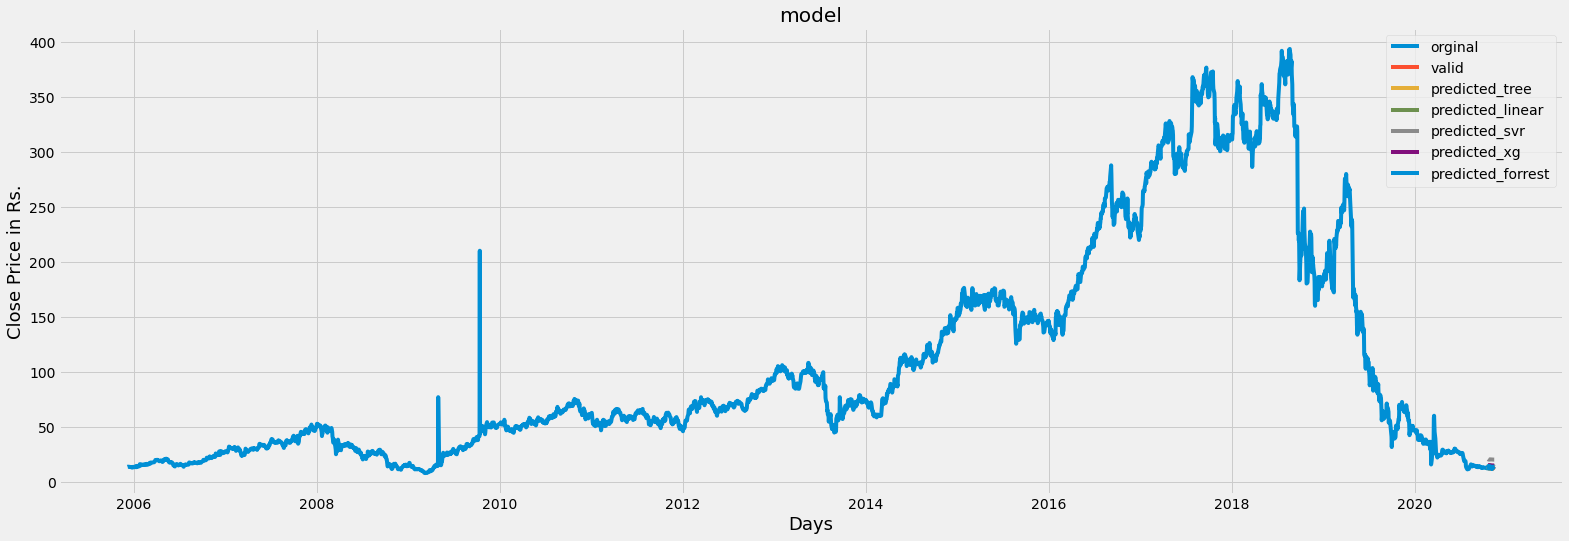

In [ ]:
prediction_tree=tree_prediction
prediction_linear=linear
prediction_svr=svm
prediction_xg=result_xg
prediction_forrest=rfc_predict
valid1=dataset[X.shape[0]:]
valid1["Predictions_tree"]=prediction_tree
valid1["Predictions_linear"]=prediction_linear
valid1["Predictions_svr"]=prediction_svr
valid1["Predictions_xg"]=prediction_xg
valid1["Predictions_forrest"]=prediction_forrest
plt.figure(figsize=(24,8))
plt.title("model")
plt.ylabel("Close Price in Rs.",fontsize=18)
plt.xlabel("Days",fontsize=18)
plt.plot(dataset["Close"])
plt.plot(valid1[["Close","Predictions_tree","Predictions_linear","Predictions_svr","Predictions_xg","Predictions_forrest"]])
plt.legend(["orginal", "valid","predicted_tree","predicted_linear","predicted_svr","predicted_xg","predicted_forrest"])
plt.show()

In [ ]:
valid1=valid1.drop("Prediction",axis=1)
valid1

,Close,Predictions_tree,Predictions_linear,Predictions_svr,Predictions_xg,Predictions_forrest
Date,,,,,,
2020-10-19,12.90,12.9000,15.625784,20.977007,15.470116,13.725125
2020-10-20,12.90,14.3300,15.183936,20.813435,15.470116,14.680017
2020-10-21,12.95,12.9500,14.840276,20.690092,15.267293,12.763857
2020-10-22,12.70,12.4125,14.791182,20.672750,15.267293,12.430375
2020-10-23,13.30,13.4000,14.594805,20.604077,15.267293,13.558429
2020-10-26,13.15,13.1500,14.987559,20.742537,15.267293,13.564213
2020-10-27,12.85,14.3300,15.183936,20.813435,15.470116,14.680017
2020-10-28,12.50,13.1500,14.987559,20.742537,15.267293,13.564213
2020-10-29,12.40,12.4125,14.791182,20.672750,15.267293,12.430375


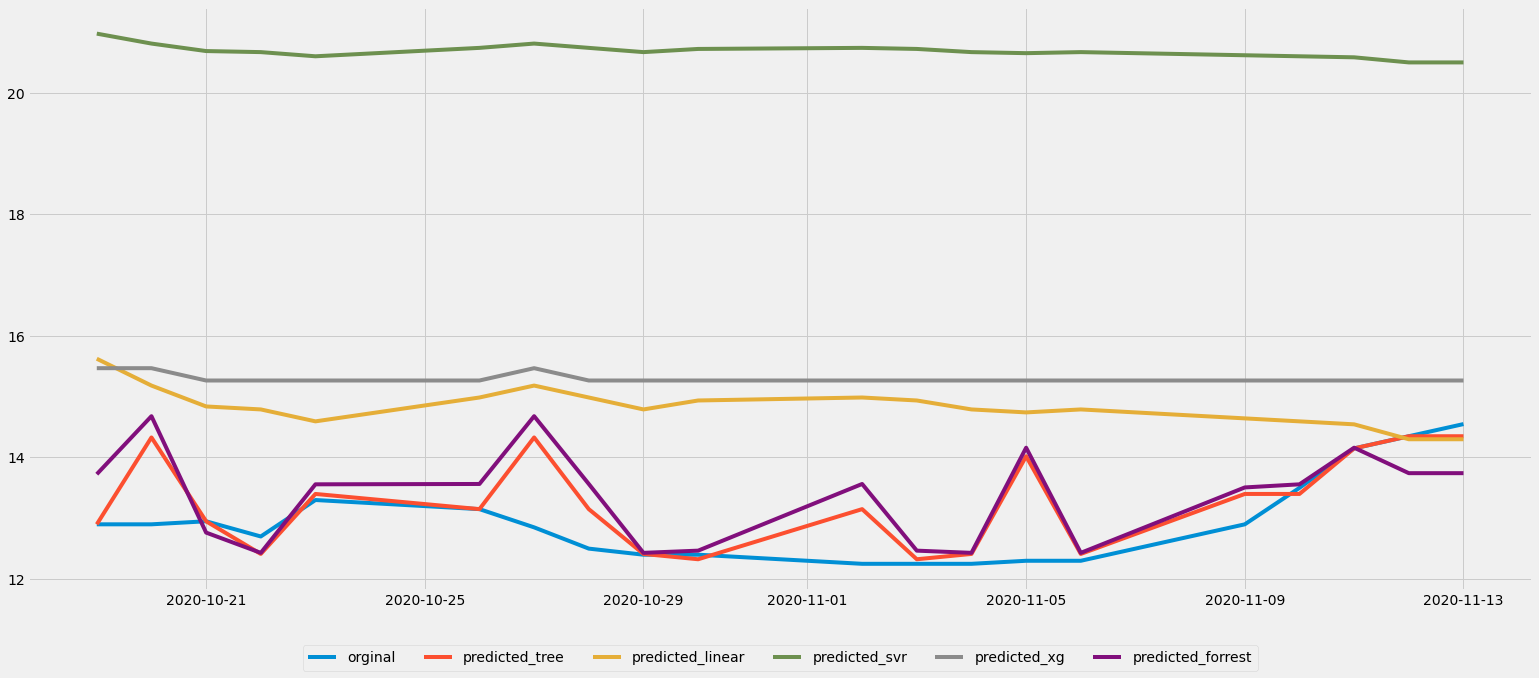

In [ ]:
plt.figure(figsize=(24,10))
plt.plot(valid1[["Close","Predictions_tree","Predictions_linear","Predictions_svr","Predictions_xg","Predictions_forrest"]])
plt.legend(["orginal","predicted_tree","predicted_linear","predicted_svr","predicted_xg","predicted_forrest"],loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol= 6)
plt.show()

# Hyperparamter tuning 

### Hyperparameter tuning of XGBOOST algrothim

In [ ]:
#Parameters for hyperparamter tuning
n_estimators=[100,200,500,1000,1500]
max_depth=[2,3,4,5]
booster=['gbtree','gblinear']
learning_rate=[0.005,0.05,0.1,0.15,0.5,0.75,1]
min_child_weight=[1,2,3,4,5,6]
base_score=[0,0.25,0.5,0.75,1.0,0.35,0.10,0.33]
hyperparameter_grid_xgb={"n_estimators":n_estimators,
                     "min_child_weight":min_child_weight,
                     "base_score":base_score,
                     "learning_rate":learning_rate,
                     "booster":booster,
                     "max_depth":max_depth}

#### RandomSerachCV

In [ ]:
#RandomSearchCV
random_cv_xg=RandomizedSearchCV(estimator=classifier, param_distributions=hyperparameter_grid_xgb,n_iter=100
                             , scoring='r2',
                             n_jobs=10, cv=6, verbose=6, random_state=12, return_train_score=True)
random_cv_xg.fit(x_train,y_train)

Fitting 6 folds for each of 100 candidates, totalling 600 fits


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:   17.9s
[Parallel(n_jobs=10)]: Done  93 tasks      | elapsed:   29.8s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:   50.1s
[Parallel(n_jobs=10)]: Done 293 tasks      | elapsed:  1.3min
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:  1.6min


[05:27:43] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


[Parallel(n_jobs=10)]: Done 600 out of 600 | elapsed:  2.1min finished


RandomizedSearchCV(cv=6, error_score=nan,
                   estimator=XGBRegressor(base_score=0.5, booster='gbtree',
                                          colsample_bylevel=1,
                                          colsample_bynode=1,
                                          colsample_bytree=1, gamma=0,
                                          importance_type='gain',
                                          learning_rate=0.1, max_delta_step=0,
                                          max_depth=3, min_child_weight=1,
                                          missing=None, n_estimators=100,
                                          n_jobs=1, nthread=None,
                                          objective='reg:linear',
                                          random_state=0, reg_alpha=...
                   iid='deprecated', n_iter=100, n_jobs=10,
                   param_distributions={'base_score': [0, 0.25, 0.5, 0.75, 1.0,
                                                

In [ ]:
random_cv_xg.best_estimator_

XGBRegressor(base_score=0.75, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0,
             importance_type='gain', learning_rate=0.05, max_delta_step=0,
             max_depth=2, min_child_weight=5, missing=None, n_estimators=100,
             n_jobs=1, nthread=None, objective='reg:linear', random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
             silent=None, subsample=1, verbosity=1)

In [ ]:
#xgboost Algorthim
classifier_random=xgboost.XGBRegressor(base_score=0.75, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0,
             importance_type='gain', learning_rate=0.05, max_delta_step=0,
             max_depth=2, min_child_weight=5, missing=None, n_estimators=100,
             n_jobs=1, nthread=None, objective='reg:linear', random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
             silent=None, subsample=1, verbosity=1)
#to predict the model
classifier_random.fit(x_train,y_train)
#to predict the model
result_xg_tuned=classifier_random.predict(x_future)
result_xg_tuned

[11:01:17] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


array([16.63833, 16.63833, 16.63833, 16.63833, 16.63833, 16.63833,
       16.63833, 16.63833, 16.63833, 16.63833, 16.63833, 16.63833,
       16.63833, 16.63833, 16.63833, 16.63833, 16.63833, 16.63833,
       16.63833, 16.63833], dtype=float32)

In [ ]:
valid1["XGboost_random"]=result_xg_tuned

In [ ]:
valid1

,Close,Predictions_tree,Predictions_linear,Predictions_svr,Predictions_xg,Predictions_forrest,XGboost_random,SMA,EWMA
Date,,,,,,,,,
2020-10-16,12.65,13.003333,15.904331,21.431083,14.981414,13.006735,16.63833,13.1875,13.601373
2020-10-19,12.90,12.900000,15.805970,21.395825,14.981414,13.405450,16.63833,13.1325,13.556123
2020-10-20,12.90,12.875000,15.363344,21.240601,14.787307,13.186407,16.63833,13.1000,13.513792
2020-10-21,12.95,12.950000,15.019080,21.123771,14.787307,12.765550,16.63833,13.0875,13.477419
2020-10-22,12.70,12.275000,14.969899,21.107360,14.787307,12.735133,16.63833,13.0650,13.427263
2020-10-23,13.30,13.400000,14.773177,21.042418,14.787307,13.421533,16.63833,13.0825,13.419052
2020-10-26,13.15,12.633333,15.166622,21.173422,14.787307,12.615220,16.63833,13.0725,13.401694
2020-10-27,12.85,12.875000,15.363344,21.240601,14.787307,13.186407,16.63833,13.0375,13.366101
2020-10-28,12.50,12.633333,15.166622,21.173422,14.787307,12.615220,16.63833,12.9950,13.310223


#### Grid SearchCV

In [ ]:
gridsearch_cv_xg=GridSearchCV(estimator=classifier,  param_grid=hyperparameter_grid_xgb,scoring='r2', n_jobs=5, cv=6, verbose=6, return_train_score=True)
gridsearch_cv_xg.fit(x_train,y_train)
gridsearch_cv_xg.best_estimator_

Fitting 6 folds for each of 13440 candidates, totalling 80640 fits


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    0.3s
[Parallel(n_jobs=5)]: Done  40 tasks      | elapsed:    8.1s
[Parallel(n_jobs=5)]: Done 103 tasks      | elapsed:   24.4s
[Parallel(n_jobs=5)]: Done 190 tasks      | elapsed:   46.6s
[Parallel(n_jobs=5)]: Done 303 tasks      | elapsed:  1.4min
[Parallel(n_jobs=5)]: Done 440 tasks      | elapsed:  2.2min
[Parallel(n_jobs=5)]: Done 603 tasks      | elapsed:  3.2min
[Parallel(n_jobs=5)]: Done 790 tasks      | elapsed:  4.4min
[Parallel(n_jobs=5)]: Done 1003 tasks      | elapsed:  5.4min
[Parallel(n_jobs=5)]: Done 1240 tasks      | elapsed:  6.7min
[Parallel(n_jobs=5)]: Done 1503 tasks      | elapsed:  8.4min
[Parallel(n_jobs=5)]: Done 1790 tasks      | elapsed:  9.7min
[Parallel(n_jobs=5)]: Done 2103 tasks      | elapsed: 11.7min
[Parallel(n_jobs=5)]: Done 2440 tasks      | elapsed: 13.3min
[Parallel(n_jobs=5)]: Done 2803 tasks      | elapsed: 15.6min
[Pa

[10:52:13] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


XGBRegressor(base_score=1.0, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0,
             importance_type='gain', learning_rate=0.05, max_delta_step=0,
             max_depth=2, min_child_weight=6, missing=None, n_estimators=100,
             n_jobs=1, nthread=None, objective='reg:linear', random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
             silent=None, subsample=1, verbosity=1)

In [ ]:
gridsearch_cv_xg.best_estimator_

XGBRegressor(base_score=1.0, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0,
             importance_type='gain', learning_rate=0.05, max_delta_step=0,
             max_depth=2, min_child_weight=6, missing=None, n_estimators=100,
             n_jobs=1, nthread=None, objective='reg:linear', random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
             silent=None, subsample=1, verbosity=1)

In [ ]:
classifier_grid=xgboost.XGBRegressor(base_score=1.0, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0,
             importance_type='gain', learning_rate=0.05, max_delta_step=0,
             max_depth=2, min_child_weight=6, missing=None, n_estimators=100,
             n_jobs=1, nthread=None, objective='reg:linear', random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
             silent=None, subsample=1, verbosity=1)
#to predict the model
classifier_grid.fit(x_train,y_train)
#to predict the model
result_xg_tuned_grid=classifier_grid.predict(x_future)
result_xg_tuned_grid

[11:05:16] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


array([16.293432, 16.293432, 16.293432, 16.293432, 16.293432, 16.293432,
       16.293432, 16.293432, 16.293432, 16.293432, 16.293432, 16.293432,
       16.293432, 16.293432, 16.293432, 16.293432, 16.293432, 16.293432,
       16.293432, 16.293432], dtype=float32)

In [ ]:
valid1["XGboost_grid"]=result_xg_tuned_grid
valid1

,Close,Predictions_tree,Predictions_linear,Predictions_svr,Predictions_xg,Predictions_forrest,XGboost_random,SMA,EWMA,XGboost_grid
Date,,,,,,,,,,
2020-10-16,12.65,13.003333,15.904331,21.431083,14.981414,13.006735,16.63833,13.1875,13.601373,16.293432
2020-10-19,12.90,12.900000,15.805970,21.395825,14.981414,13.405450,16.63833,13.1325,13.556123,16.293432
2020-10-20,12.90,12.875000,15.363344,21.240601,14.787307,13.186407,16.63833,13.1000,13.513792,16.293432
2020-10-21,12.95,12.950000,15.019080,21.123771,14.787307,12.765550,16.63833,13.0875,13.477419,16.293432
2020-10-22,12.70,12.275000,14.969899,21.107360,14.787307,12.735133,16.63833,13.0650,13.427263,16.293432
2020-10-23,13.30,13.400000,14.773177,21.042418,14.787307,13.421533,16.63833,13.0825,13.419052,16.293432
2020-10-26,13.15,12.633333,15.166622,21.173422,14.787307,12.615220,16.63833,13.0725,13.401694,16.293432
2020-10-27,12.85,12.875000,15.363344,21.240601,14.787307,13.186407,16.63833,13.0375,13.366101,16.293432
2020-10-28,12.50,12.633333,15.166622,21.173422,14.787307,12.615220,16.63833,12.9950,13.310223,16.293432


### Hyperparramter tuning for Linear regression

In [ ]:
#Setting parameters
copy_X=[True,False]
fit_intercept=[False,True]
n_jobs=[1,2,3,4,5]
normalize=[True,False]
#to train the data into the model
hyperparameter_grid_lr={"normalize":normalize,
                     "n_jobs":n_jobs,
                     "fit_intercept":fit_intercept,
                     "copy_X":copy_X}

#### Random Search for linear






In [ ]:
#RandomSearchCV
random_cv_lr=RandomizedSearchCV(estimator=std_reg,param_distributions=hyperparameter_grid_lr,n_iter=100
                             , scoring='r2',
                             n_jobs=10, cv=6, verbose=6, random_state=12, return_train_score=True)
random_cv_lr.fit(x_train,y_train)

/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 40 is smaller than n_iter=100. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


Fitting 6 folds for each of 40 candidates, totalling 240 fits


[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    2.4s
[Parallel(n_jobs=10)]: Done 173 tasks      | elapsed:    3.0s
[Parallel(n_jobs=10)]: Done 240 out of 240 | elapsed:    3.5s finished


RandomizedSearchCV(cv=6, error_score=nan,
                   estimator=LinearRegression(copy_X=True, fit_intercept=True,
                                              n_jobs=None, normalize=False),
                   iid='deprecated', n_iter=100, n_jobs=10,
                   param_distributions={'copy_X': [True, False],
                                        'fit_intercept': [False, True],
                                        'n_jobs': [1, 2, 3, 4, 5],
                                        'normalize': [True, False]},
                   pre_dispatch='2*n_jobs', random_state=12, refit=True,
                   return_train_score=True, scoring='r2', verbose=6)

In [ ]:
random_cv_lr.best_estimator_

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=True)

In [ ]:
#linear regression
std_reg_random=LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=True)
#to train the data into the model
std_reg_random.fit(x_train,y_train)
#linear prediction
random_linear=std_reg_random.predict(x_future)
random_linear

array([15.90433138, 15.80596976, 15.36334437, 15.01907965, 14.96989884,
       14.77317655, 15.16662207, 15.36334437, 15.16662207, 14.96989884,
       15.11744127, 15.16662207, 15.11744127, 14.96989884, 14.92071897,
       14.96989884, 14.82235736, 14.77317655, 14.72399574, 14.47809264])

#### GridSearchCV for linear

In [ ]:
#GridSearchCV 
gridsearch_cv_lr=GridSearchCV(estimator=std_reg,  param_grid=hyperparameter_grid_lr,scoring='r2', n_jobs=5, cv=6, verbose=6, return_train_score=True)
gridsearch_cv_lr.fit(x_train,y_train)

Fitting 6 folds for each of 40 candidates, totalling 240 fits


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done 166 tasks      | elapsed:    0.3s
[Parallel(n_jobs=5)]: Done 240 out of 240 | elapsed:    0.4s finished


GridSearchCV(cv=6, error_score=nan,
             estimator=LinearRegression(copy_X=True, fit_intercept=True,
                                        n_jobs=None, normalize=False),
             iid='deprecated', n_jobs=5,
             param_grid={'copy_X': [True, False],
                         'fit_intercept': [False, True],
                         'n_jobs': [1, 2, 3, 4, 5],
                         'normalize': [True, False]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
             scoring='r2', verbose=6)

In [ ]:
gridsearch_cv_lr.best_estimator_

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=True)

In [ ]:
#Linear regression
std_reg_grid=LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=True)
#to train the data into the model
std_reg_grid.fit(x_train,y_train)
#linear prediction
grid_linear=std_reg_grid.predict(x_future)
grid_linear

array([15.90433138, 15.80596976, 15.36334437, 15.01907965, 14.96989884,
       14.77317655, 15.16662207, 15.36334437, 15.16662207, 14.96989884,
       15.11744127, 15.16662207, 15.11744127, 14.96989884, 14.92071897,
       14.96989884, 14.82235736, 14.77317655, 14.72399574, 14.47809264])

In [ ]:
valid1["linear_grid"]=grid_linear
valid1["linear_random"]=random_linear
valid1

,Close,Predictions_tree,Predictions_linear,Predictions_svr,Predictions_xg,Predictions_forrest,XGboost_random,SMA,EWMA,XGboost_grid,linear_grid,linear_random
Date,,,,,,,,,,,,
2020-10-16,12.65,13.003333,15.904331,21.431083,14.981414,13.006735,16.63833,13.1875,13.601373,16.293432,15.904331,15.904331
2020-10-19,12.90,12.900000,15.805970,21.395825,14.981414,13.405450,16.63833,13.1325,13.556123,16.293432,15.805970,15.805970
2020-10-20,12.90,12.875000,15.363344,21.240601,14.787307,13.186407,16.63833,13.1000,13.513792,16.293432,15.363344,15.363344
2020-10-21,12.95,12.950000,15.019080,21.123771,14.787307,12.765550,16.63833,13.0875,13.477419,16.293432,15.019080,15.019080
2020-10-22,12.70,12.275000,14.969899,21.107360,14.787307,12.735133,16.63833,13.0650,13.427263,16.293432,14.969899,14.969899
2020-10-23,13.30,13.400000,14.773177,21.042418,14.787307,13.421533,16.63833,13.0825,13.419052,16.293432,14.773177,14.773177
2020-10-26,13.15,12.633333,15.166622,21.173422,14.787307,12.615220,16.63833,13.0725,13.401694,16.293432,15.166622,15.166622
2020-10-27,12.85,12.875000,15.363344,21.240601,14.787307,13.186407,16.63833,13.0375,13.366101,16.293432,15.363344,15.363344
2020-10-28,12.50,12.633333,15.166622,21.173422,14.787307,12.615220,16.63833,12.9950,13.310223,16.293432,15.166622,15.166622


### HyperParamater Tuning of Decision Tree

In [ ]:
#Parameters
criterion=['mse','friedman_mse','mae']
splitter=['best','random']
max_depth=[1,2,3,4,5,6,7,8,9,10]
min_samples_split=[2,4,6,8] 
min_samples_leaf=[1,2,3,4]

hyperparameter_grid_dtr={'criterion':criterion,
                         'splitter':splitter,
                         'max_depth':max_depth,
                         'min_samples_split':min_samples_split,
                         'min_samples_leaf':min_samples_leaf
}                        

#### RandomSearchCV for Decision Tree

In [ ]:
random_cv_dtc=RandomizedSearchCV(estimator=tree,param_distributions=hyperparameter_grid_dtr,n_iter=100
                             , scoring='r2',
                             n_jobs=10, cv=6, verbose=6, random_state=12, return_train_score=True)
random_cv_dtc.fit(x_train,y_train)

Fitting 6 folds for each of 100 candidates, totalling 600 fits


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.8s
[Parallel(n_jobs=10)]: Done  93 tasks      | elapsed:    2.3s
[Parallel(n_jobs=10)]: Done 230 tasks      | elapsed:    4.1s
[Parallel(n_jobs=10)]: Done 456 tasks      | elapsed:    6.2s
[Parallel(n_jobs=10)]: Done 581 out of 600 | elapsed:    7.4s remaining:    0.2s
[Parallel(n_jobs=10)]: Done 600 out of 600 | elapsed:    7.6s finished


RandomizedSearchCV(cv=6, error_score=nan,
                   estimator=DecisionTreeRegressor(ccp_alpha=0.0,
                                                   criterion='mse',
                                                   max_depth=None,
                                                   max_features=None,
                                                   max_leaf_nodes=None,
                                                   min_impurity_decrease=0.0,
                                                   min_impurity_split=None,
                                                   min_samples_leaf=1,
                                                   min_samples_split=2,
                                                   min_weight_fraction_leaf=0.0,
                                                   presort='deprecated',
                                                   random_state=None,
                                                   splitter='best'),
                   iid='d

In [ ]:
random_cv_dtc.best_estimator_

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=4,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=4, min_samples_split=4,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=None, splitter='best')

In [ ]:
#Decision regression
tree_random=DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=4,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=4, min_samples_split=4,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=None, splitter='best')
#to train the data into the model
tree_random.fit(x_train,y_train)
#for tree prediction
tree_random_prediction=tree_random.predict(x_future)
print(tree_random_prediction)

[16.59538224 16.59538224 16.59538224 16.59538224 16.59538224 16.59538224
 16.59538224 16.59538224 16.59538224 16.59538224 16.59538224 16.59538224
 16.59538224 16.59538224 16.59538224 16.59538224 16.59538224 16.59538224
 16.59538224 16.59538224]


#### GridSearchCV of decision tree

In [ ]:
#GridSearchCV 
gridsearch_cv_dtc=GridSearchCV(estimator=tree,  param_grid=hyperparameter_grid_dtr,scoring='r2', n_jobs=5, cv=6, verbose=6, return_train_score=True)
gridsearch_cv_dtc.fit(x_train,y_train)

Fitting 6 folds for each of 960 candidates, totalling 5760 fits


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Done 150 tasks      | elapsed:    0.3s
[Parallel(n_jobs=5)]: Done 2006 tasks      | elapsed:    3.8s
[Parallel(n_jobs=5)]: Done 4476 tasks      | elapsed:   16.2s
[Parallel(n_jobs=5)]: Done 4792 tasks      | elapsed:   22.0s
[Parallel(n_jobs=5)]: Done 5340 tasks      | elapsed:   34.0s
[Parallel(n_jobs=5)]: Done 5760 out of 5760 | elapsed:   43.6s finished


GridSearchCV(cv=6, error_score=nan,
             estimator=DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse',
                                             max_depth=None, max_features=None,
                                             max_leaf_nodes=None,
                                             min_impurity_decrease=0.0,
                                             min_impurity_split=None,
                                             min_samples_leaf=1,
                                             min_samples_split=2,
                                             min_weight_fraction_leaf=0.0,
                                             presort='deprecated',
                                             random_state=None,
                                             splitter='best'),
             iid='deprecated', n_jobs=5,
             param_grid={'criterion': ['mse', 'friedman_mse', 'mae'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                 

In [ ]:
gridsearch_cv_dtc.best_estimator_

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=9,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=4, min_samples_split=6,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=None, splitter='random')

In [ ]:
  #Decision regression
  tree_grid=DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=9,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=4, min_samples_split=6,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=None, splitter='random')
  #to train the data into the model
  tree_grid.fit(x_train,y_train)
  #for tree prediction
  tree_grid_prediction=tree_grid.predict(x_future)
  tree_grid_prediction

array([13.88959178, 13.88959178, 13.88959178, 13.88959178, 13.88959178,
       13.88959178, 13.88959178, 13.88959178, 13.88959178, 13.88959178,
       13.88959178, 13.88959178, 13.88959178, 13.88959178, 13.88959178,
       13.88959178, 13.88959178, 13.88959178, 13.88959178, 13.88959178])

In [ ]:
valid1["tree_grid"]=tree_grid_prediction
valid1["tree_random"]=tree_random_prediction
valid1

,Close,Predictions_tree,Predictions_linear,Predictions_svr,Predictions_xg,Predictions_forrest,XGboost_random,SMA,EWMA,XGboost_grid,linear_grid,linear_random,tree_grid,tree_random
Date,,,,,,,,,,,,,,
2020-10-16,12.65,13.003333,15.904331,21.431083,14.981414,13.006735,16.63833,13.1875,13.601373,16.293432,15.904331,15.904331,13.889592,16.595382
2020-10-19,12.90,12.900000,15.805970,21.395825,14.981414,13.405450,16.63833,13.1325,13.556123,16.293432,15.805970,15.805970,13.889592,16.595382
2020-10-20,12.90,12.875000,15.363344,21.240601,14.787307,13.186407,16.63833,13.1000,13.513792,16.293432,15.363344,15.363344,13.889592,16.595382
2020-10-21,12.95,12.950000,15.019080,21.123771,14.787307,12.765550,16.63833,13.0875,13.477419,16.293432,15.019080,15.019080,13.889592,16.595382
2020-10-22,12.70,12.275000,14.969899,21.107360,14.787307,12.735133,16.63833,13.0650,13.427263,16.293432,14.969899,14.969899,13.889592,16.595382
2020-10-23,13.30,13.400000,14.773177,21.042418,14.787307,13.421533,16.63833,13.0825,13.419052,16.293432,14.773177,14.773177,13.889592,16.595382
2020-10-26,13.15,12.633333,15.166622,21.173422,14.787307,12.615220,16.63833,13.0725,13.401694,16.293432,15.166622,15.166622,13.889592,16.595382
2020-10-27,12.85,12.875000,15.363344,21.240601,14.787307,13.186407,16.63833,13.0375,13.366101,16.293432,15.363344,15.363344,13.889592,16.595382
2020-10-28,12.50,12.633333,15.166622,21.173422,14.787307,12.615220,16.63833,12.9950,13.310223,16.293432,15.166622,15.166622,13.889592,16.595382


### hyperparameter tuning of Random Forrest

In [ ]:
#parameter for setting
n_estimators=[100,150,200,250,300]
criterion=["mse", "mae"]
max_depth=[1,2,3,4,5]
min_samples_split=[2,4,6,8] 
min_samples_leaf=[1,2,3,4]
max_features=['auto', 'sqrt', 'log2']

hyperparameter_grid_rf={'criterion':criterion,
                         'n_estimators':n_estimators,
                         'max_features':max_features,
                         'max_depth':max_depth,
                         'min_samples_split':min_samples_split,
                         'min_samples_leaf':min_samples_leaf
} 

#### RandomSearchCV Random Forrest

In [ ]:
random_cv_rf=RandomizedSearchCV(estimator=rfc,param_distributions=hyperparameter_grid_rf,n_iter=100
                             , scoring='r2',
                             n_jobs=10, cv=6, verbose=6, random_state=12, return_train_score=True)
random_cv_rf.fit(x_train,y_train)

Fitting 6 folds for each of 100 candidates, totalling 600 fits


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:   35.4s
[Parallel(n_jobs=10)]: Done  93 tasks      | elapsed:  1.2min
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:  2.6min
[Parallel(n_jobs=10)]: Done 293 tasks      | elapsed:  4.9min
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:  7.1min
[Parallel(n_jobs=10)]: Done 600 out of 600 | elapsed: 10.2min finished


RandomizedSearchCV(cv=6, error_score=nan,
                   estimator=RandomForestRegressor(bootstrap=True,
                                                   ccp_alpha=0.0,
                                                   criterion='mse',
                                                   max_depth=None,
                                                   max_features='auto',
                                                   max_leaf_nodes=None,
                                                   max_samples=None,
                                                   min_impurity_decrease=0.0,
                                                   min_impurity_split=None,
                                                   min_samples_leaf=1,
                                                   min_samples_split=2,
                                                   min_weight_fraction_leaf=0.0,
                                                   n_estimators=100,
                              

In [ ]:
random_cv_rf.best_estimator_

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=5, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=4,
                      min_samples_split=8, min_weight_fraction_leaf=0.0,
                      n_estimators=200, n_jobs=None, oob_score=False,
                      random_state=None, verbose=0, warm_start=False)

In [ ]:
#RandomForestRegressor
rfc_tuned_random= RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=5, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=4,
                      min_samples_split=8, min_weight_fraction_leaf=0.0,
                      n_estimators=200, n_jobs=None, oob_score=False,
                      random_state=None, verbose=0, warm_start=False)
#to train the model
rfc_tuned_random.fit(x_train,y_train)
#Predeiction
rfc_tuned_random_val=rfc_tuned_random.predict(x_future)
rfc_tuned_random_val

array([14.71277244, 14.71277244, 14.71277244, 14.71277244, 14.71277244,
       14.71277244, 14.71277244, 14.71277244, 14.71277244, 14.71277244,
       14.71277244, 14.71277244, 14.71277244, 14.71277244, 14.71277244,
       14.71277244, 14.71277244, 14.71277244, 14.71277244, 14.71277244])

#### Grid Search for Random Forrest






In [ ]:
# GridSearchCV 
gridsearch_cv_rfc=GridSearchCV(estimator=rfc,param_grid=hyperparameter_grid_rf,scoring='r2', n_jobs=5, cv=6, verbose=6, return_train_score=True)
gridsearch_cv_rfc.fit(x_train,y_train)

NameError: ignored

In [ ]:
gridsearch_cv_rfc.best_estimator_

In [ ]:
#RandomForestRegressor
rfc_tuned_grid= RandomForestRegressor()
#to train the model
rfc_tuned_grid.fit(x_train,y_train)
#Predeiction
rfc_tuned_grid_val=rfc_tuned_grid.predict(x_future)
rfc_tuned_grid_val

In [ ]:
valid1["forrest_grid"]=rfc_tuned_grid_val
valid1["forrest_random"]=rfc_tuned_random_val
valid1

### hyperparmeter tuning of SVR


In [ ]:
#parameter
kernel=['linear', 'poly', 'rbf', 'sigmoid']
degree=[1,2,3,4,5]
gamma=['scale', 'auto'] 
C=[1,5,10]
hyperparameter_grid_svr={"kernel":kernel,"degree":degree,"gamma":gamma,"C":C}

#### GridSearchCV For SVR

In [ ]:
#GridSearchCV
gridsearch_cv_svr=GridSearchCV(estimator=svr,param_grid=hyperparameter_grid_svr,scoring='r2', n_jobs=4, cv=3, verbose=6, return_train_score=True)
gridsearch_cv_svr.fit(x_train,y_train)

Fitting 3 folds for each of 120 candidates, totalling 360 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    5.9s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.6min


In [ ]:
gridsearch_cv_svr.best_estimator_

NameError: ignored

In [ ]:
svr_grid=SVR(C=10.0, cache_size=200, coef0=0.0, degree=1, epsilon=0.1, gamma='scale',
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)
#to train the data into the model
svr_grid.fit(x_train,y_train)
#svr prediction
grid_svr=svr_grid.predict(x_future)
grid_svr

#### RandomSearchcCV FOR SVR

In [ ]:
#RandomSearchCV
random_cv_svr=RandomizedSearchCV(estimator=svr,param_distributions=svr_hyper,n_iter=100
                             , scoring='r2',
                             n_jobs=4, cv=3, verbose=6, random_state=12, return_train_score=True)
random_cv_svr.fit(x_train,y_train)

In [ ]:
random_cv_svr.best_estimator_

In [ ]:
#SVM
svr_random=SVR(C=10.0, cache_size=200, coef0=0.0, degree=1, epsilon=0.1, gamma='scale',
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)
#to train the data into the model
svr_random.fit(x_train,y_train)
#linear prediction
random_svr=svr_random.predict(x_future)
random_svr

In [ ]:
valid1["svr_grid"]=grid_svr
valid1["svr_random"]=random_svr
valid1

# Times series analysis

## Simple Moving average

In [ ]:
dft=pd.DataFrame(df["Close"])
dft

,Close
Date,
2005-12-07,14.05
2005-12-08,14.18
2005-12-09,14.20
2005-12-12,13.96
2005-12-13,14.02
...,...
2020-11-09,12.90
2020-11-10,13.50
2020-11-11,14.15


In [ ]:
#moving average or rolling mean of 30days
dft["Close_roll"]=dft["Close"].rolling(20).mean()

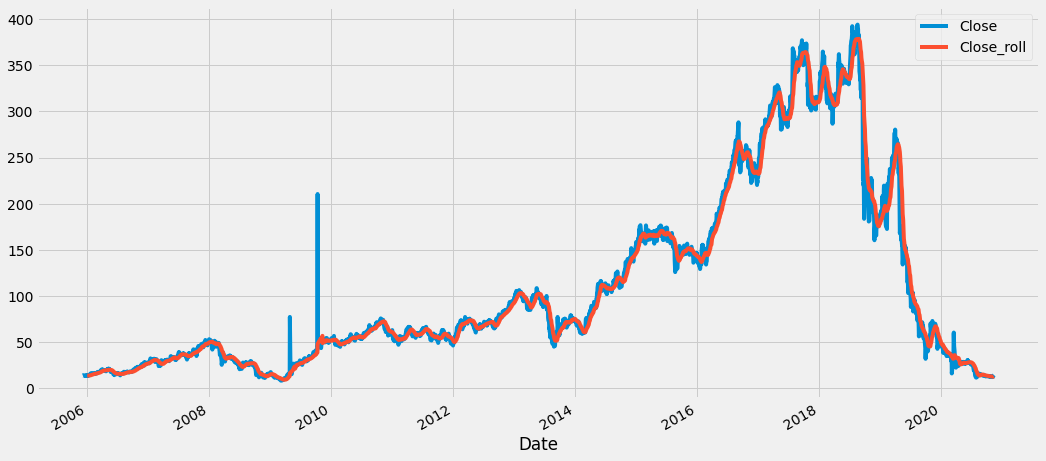

In [ ]:
dft[["Close","Close_roll"]].plot(figsize=(16,8))

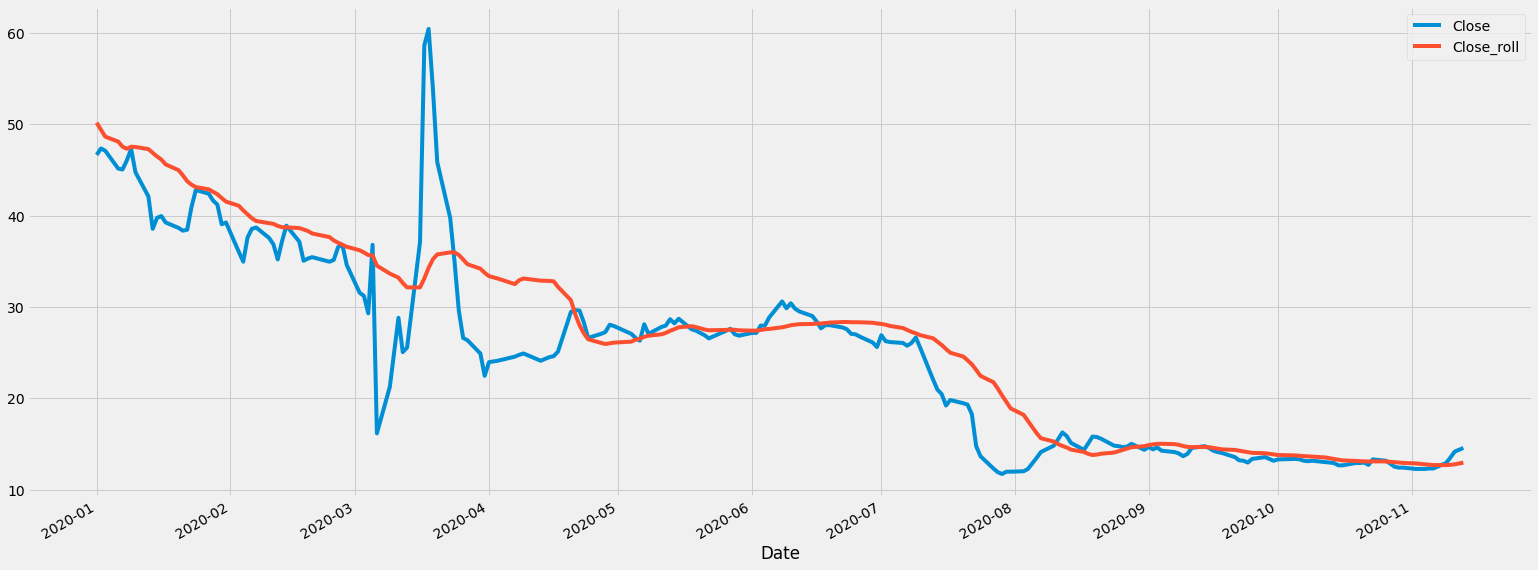

In [ ]:
#since its not clear we have taken the less entries so the graph is visble
dft[["Close","Close_roll"]]["2020-01-01":end].plot(figsize=(24,10))

bollinger bands  are envelopes plotted at a standard deviation level above and below a simple moving average of the price.
4 line to make them 
1)Rolling mean of 30 days
2)upper band = 30 days moving average + 2* s.d.
3)lower band = 30 days moving average - 2* s.d.
4) close price 


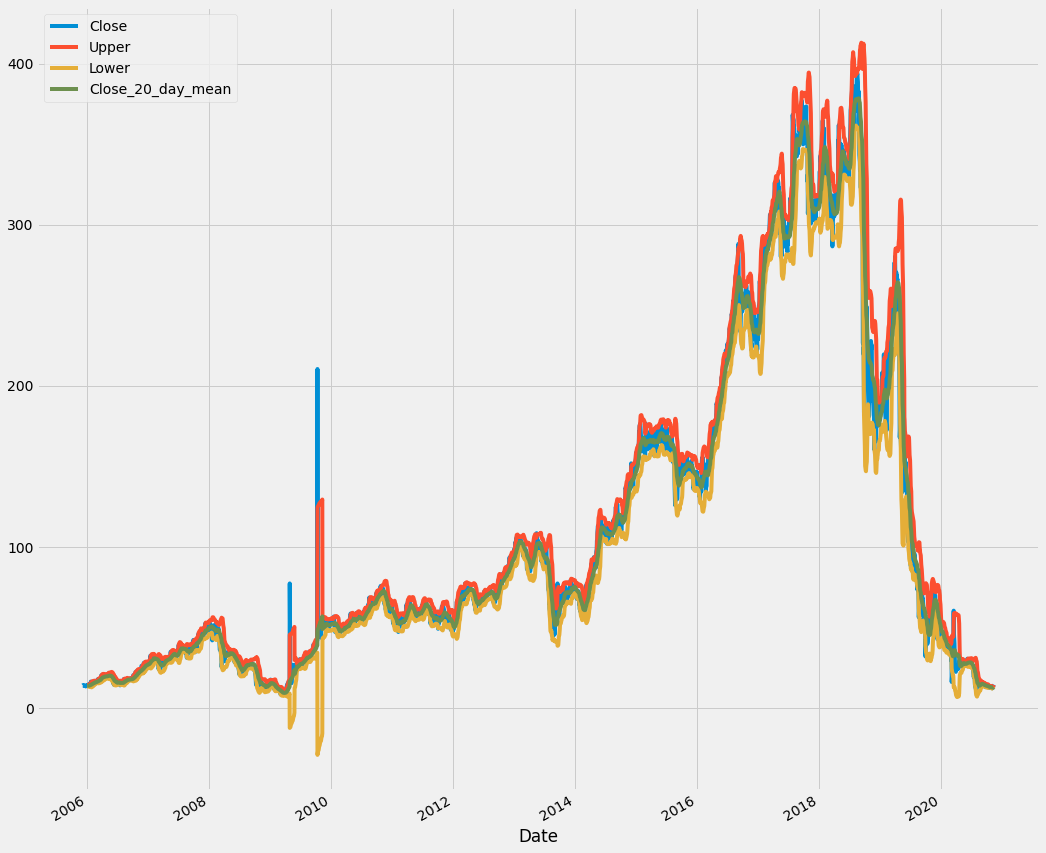

In [ ]:
dft["Close_20_day_mean"]=dft["Close"].rolling(20).mean()
dft["Upper"]=dft["Close_20_day_mean"] + 2*(dft["Close"].rolling(20).std())
dft["Lower"]=dft["Close_20_day_mean"] - 2*(dft["Close"].rolling(20).std())
dft[["Close","Upper","Lower","Close_20_day_mean"]].plot(figsize=(16,16))


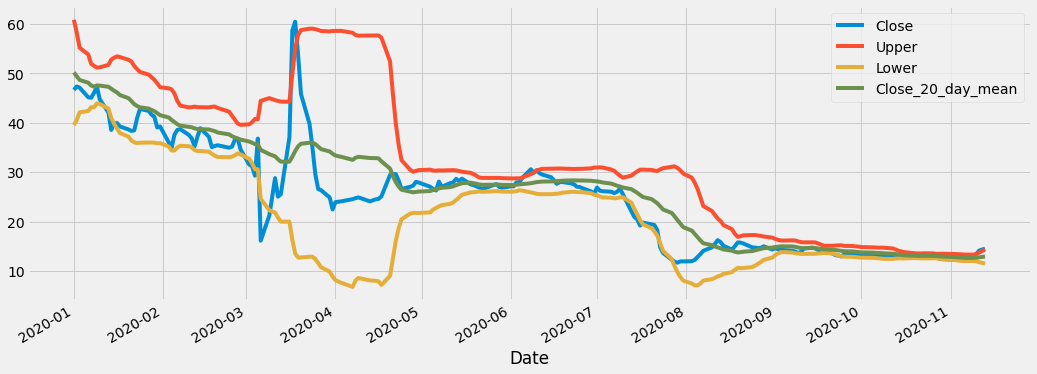

In [ ]:
#since its not clear we have taken the less entries so the graph is visble
dft[["Close","Upper","Lower","Close_20_day_mean"]]["2020-01-01":end].plot(figsize=(16,6))

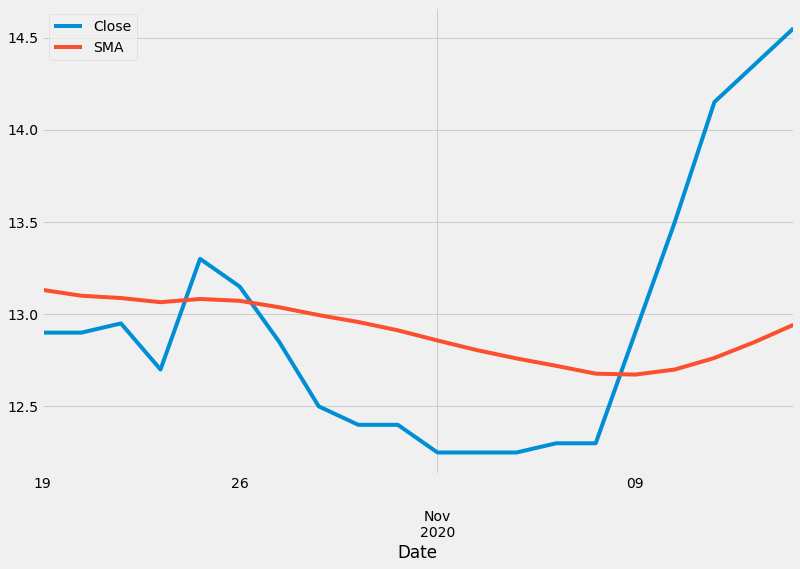

In [ ]:
valid1["SMA"]=dft["Close_roll"].iloc[3524:]
valid1[['Close','SMA']].plot(figsize=(12,8))

Now we will se the trend of the data with help of hp filter


In [ ]:
#now we will take the trend aof the close with the help of statmodels
close_cycle,close_trend=sm.tsa.filters.hpfilter(dft["Close"])

In [ ]:
dft["Close_trend"]=close_trend
dft["Close_cycle"]=close_cycle

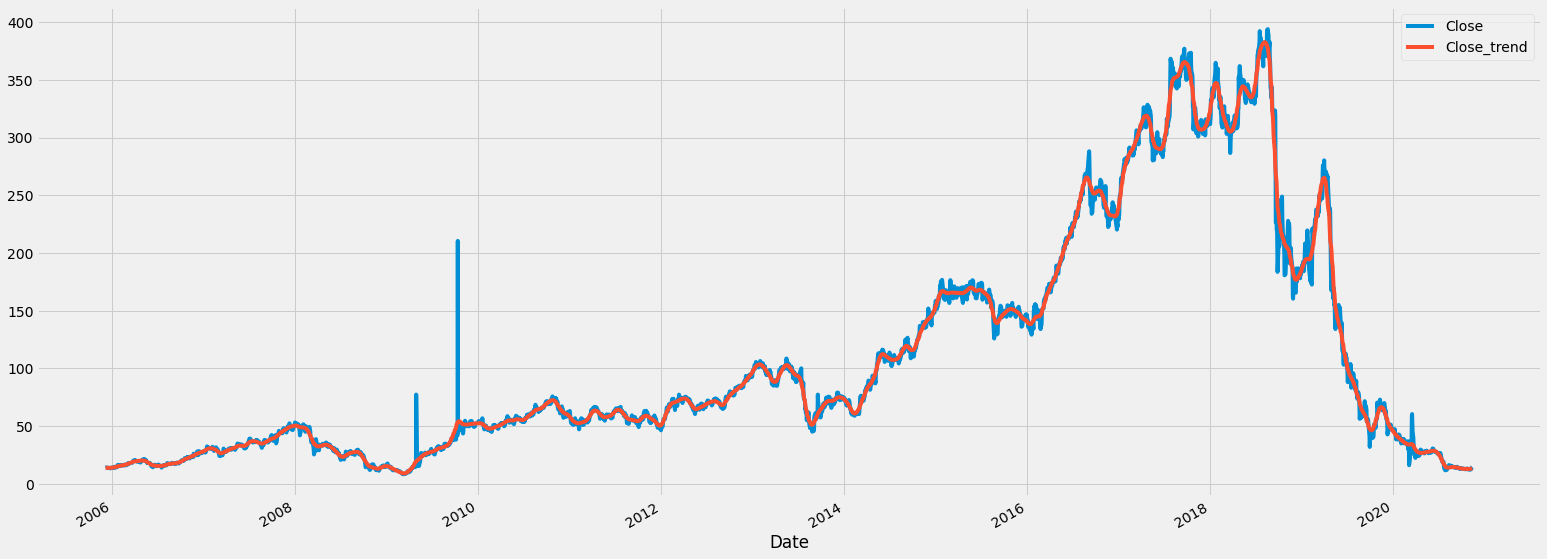

In [ ]:
dft[["Close","Close_trend"]].plot(figsize=(24,10))

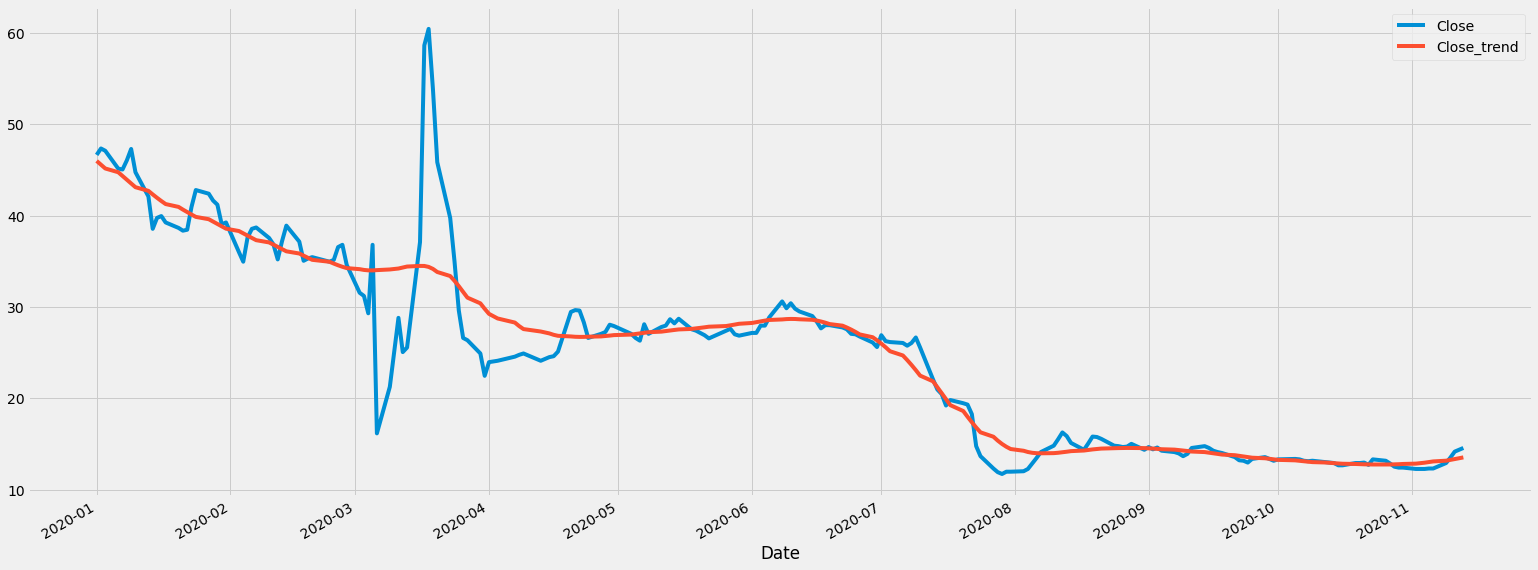

In [ ]:
#since its not clear we have taken the less entries so the graph is visble
dft[["Close","Close_trend"]]["2020-01-01":end].plot(figsize=(24,10))

## EWMA analysis

In [ ]:
dft["EWMA_20days"]=dft["Close"].ewm(span=20).mean()

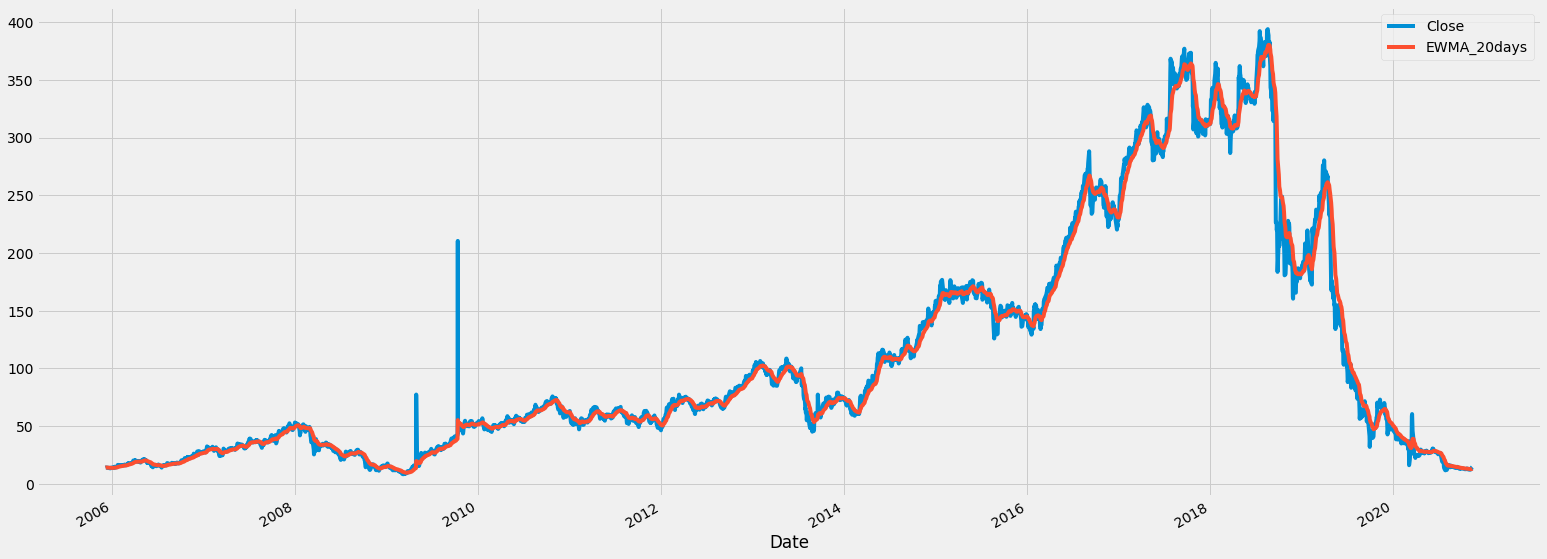

In [ ]:
dft[["Close","EWMA_20days"]].plot(figsize=(24,10))

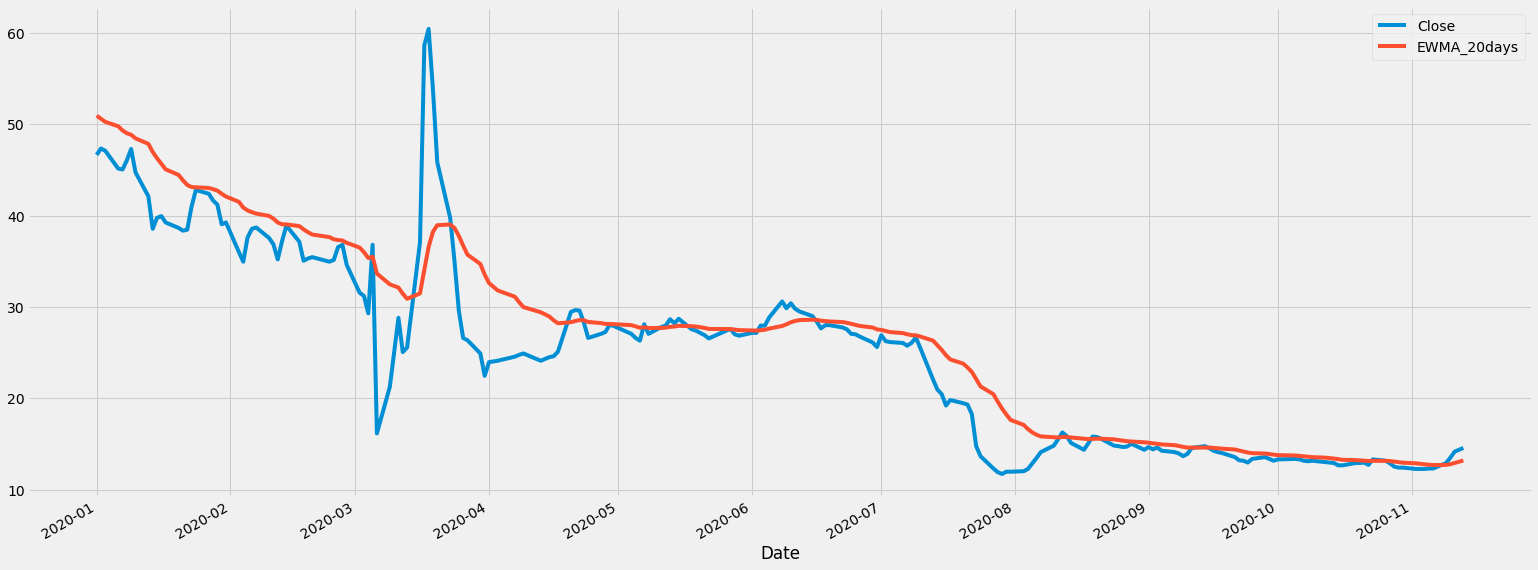

In [ ]:
#since its not clear we have taken the less entries so the graph is visble
dft[["Close","EWMA_20days"]]["2020-01-01":end].plot(figsize=(24,10))

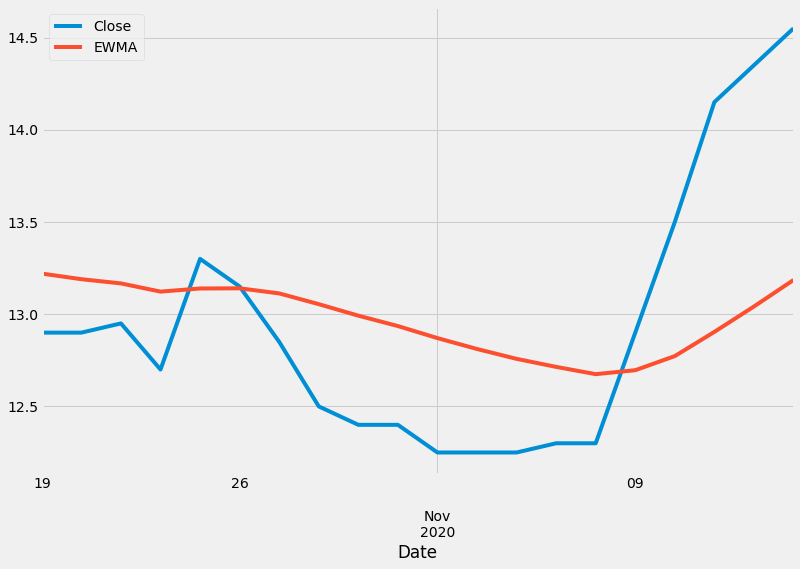

In [ ]:
valid1["EWMA"]=dft["EWMA_20days"].iloc[3524:]
valid1[['Close','EWMA']].plot(figsize=(12,8))

## ETS analysis

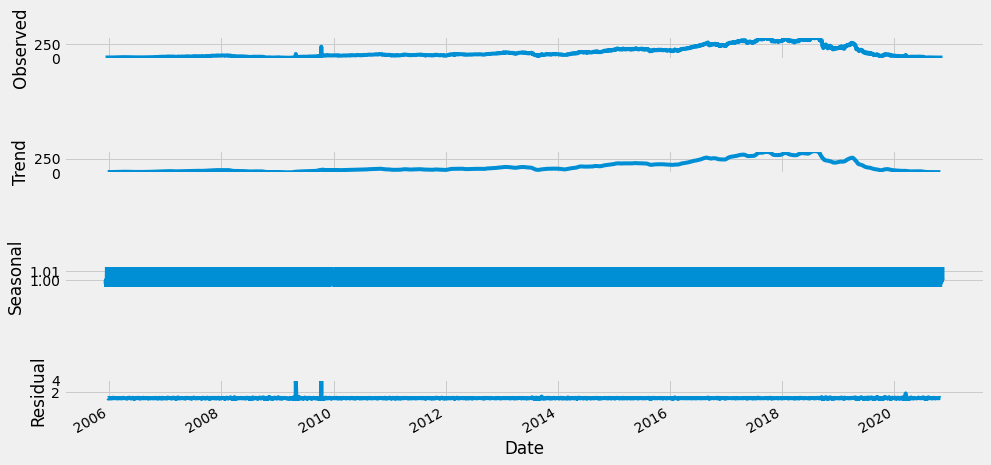

In [ ]:
ETS=seasonal_decompose(dft["Close"], model='multiplicative', filt=None, freq=20, two_sided=True, extrapolate_trend=0)
#now saving all the ETS values to dataframe
dft["ETS_trend"]=ETS.trend
dft["ETS_seasonal"]=ETS.seasonal
dft["ETS_resid"]=ETS.resid
#Plotting of ETS
fig=ETS.plot()
figure = matplotlib.pyplot.gcf()
fig.set_size_inches(16,8)

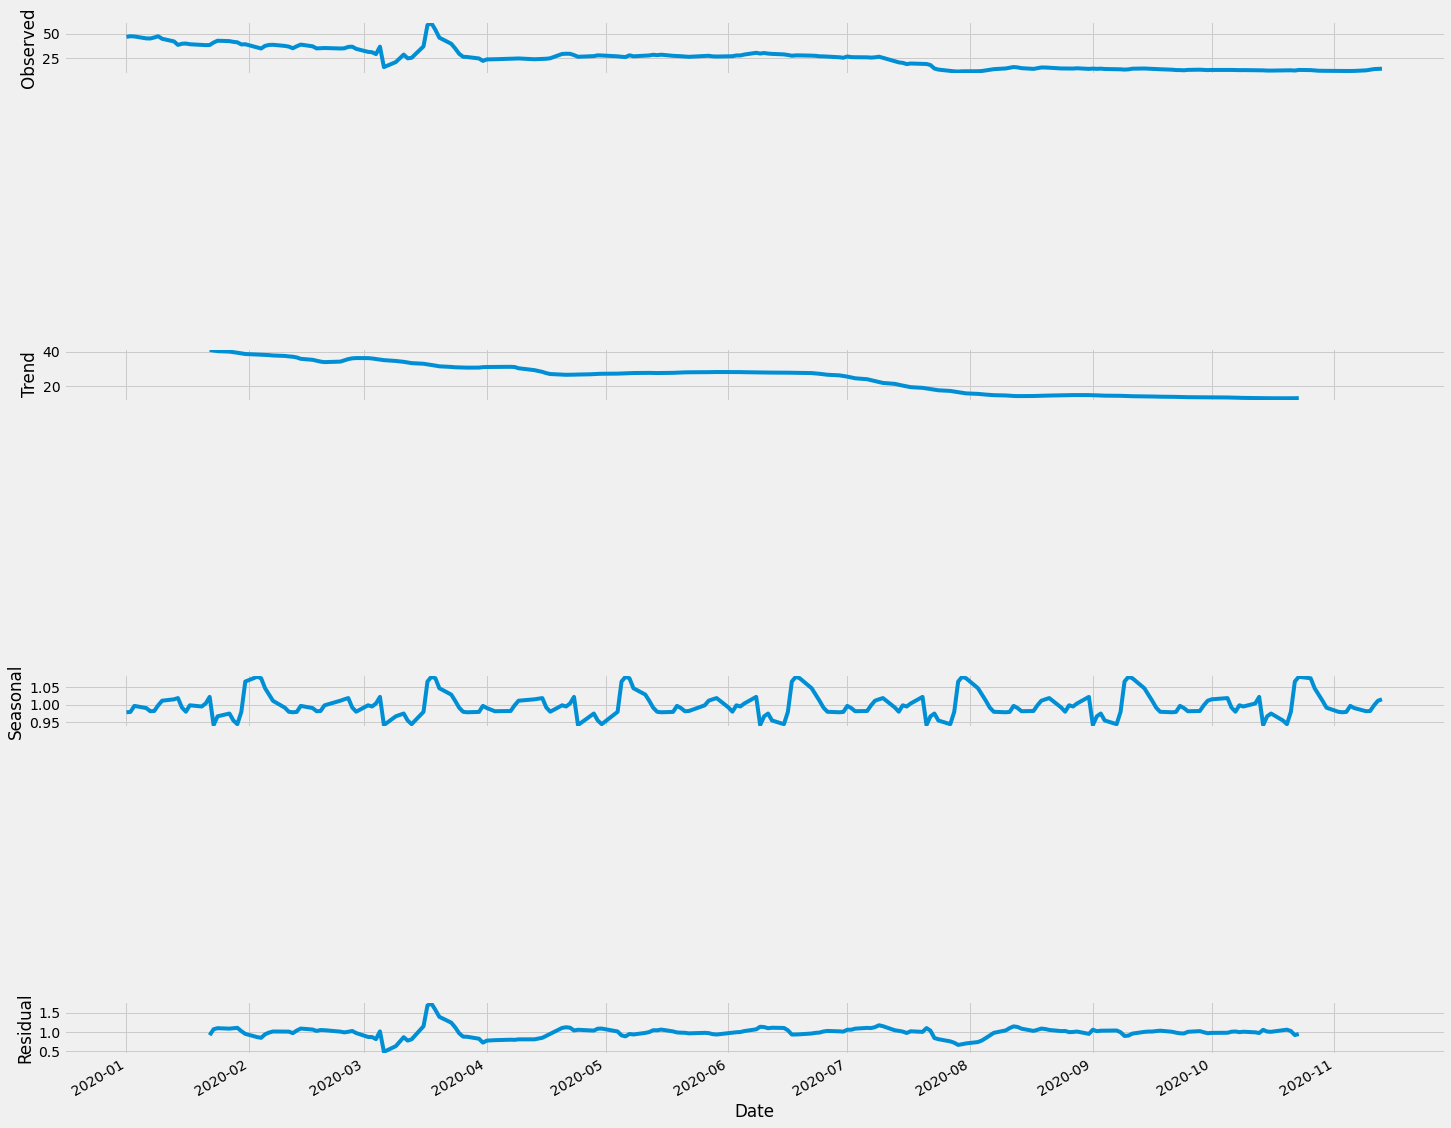

In [ ]:
#since its not clear we have taken the less entries so the graph is visble
ETS=seasonal_decompose(dft["Close"]["2020-01-01":end],model="multiplicative",freq=30)
fig=ETS.plot()
figure = matplotlib.pyplot.gcf()
fig.set_size_inches(24,24)

## ARIMA analysis


The general process for ARIMA models is the following:

Visualize the Time Series Data
Make the time series data stationary
Plot the Correlation and AutoCorrelation Charts
Construct the ARIMA Model
Use the model to make predictions


In [ ]:
#To check if the data is stationary or not we will use
result = adfuller(dft["Close"])
# Store in a function for later use!
def adf_check(time_series):
    """
    Pass in a time series, returns ADF report
    """
    result = adfuller(time_series)
    print('Augmented Dickey-Fuller Test:')
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']

    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [ ]:
adf_check(dft["Close"])

Augmented Dickey-Fuller Test:
ADF Test Statistic : -1.282285525802219
p-value : 0.6372372398246116
#Lags Used : 2
Number of Observations Used : 3673
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [ ]:
dft["First_order_Difference"]=dft["Close"]-dft["Close"].shift(1)

In [ ]:
adf_check(dft["First_order_Difference"].dropna())

Augmented Dickey-Fuller Test:
ADF Test Statistic : -50.53730951791265
p-value : 0.0
#Lags Used : 1
Number of Observations Used : 3673
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


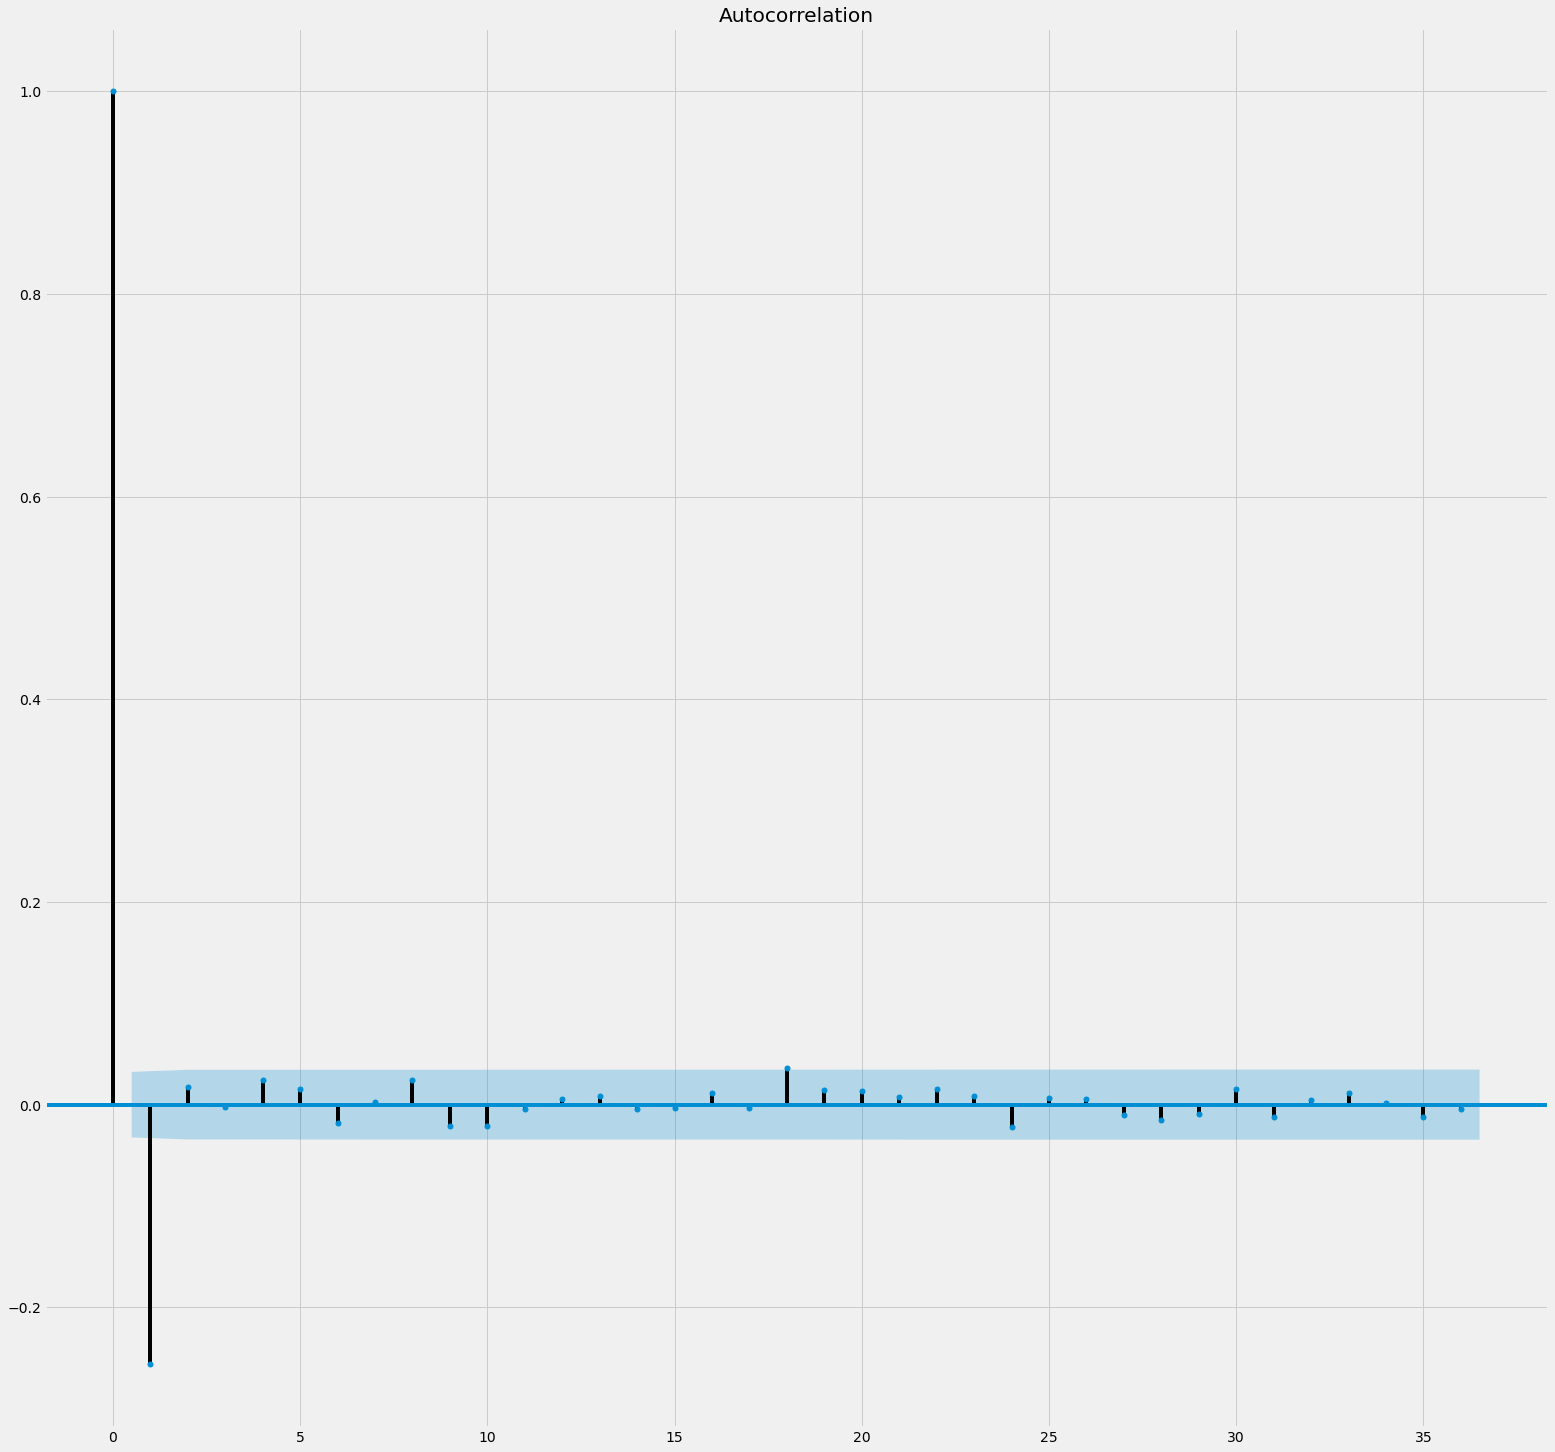

In [ ]:
fig_acp=plot_acf(dft["First_order_Difference"].dropna())
fig_acp.set_size_inches(24,24)

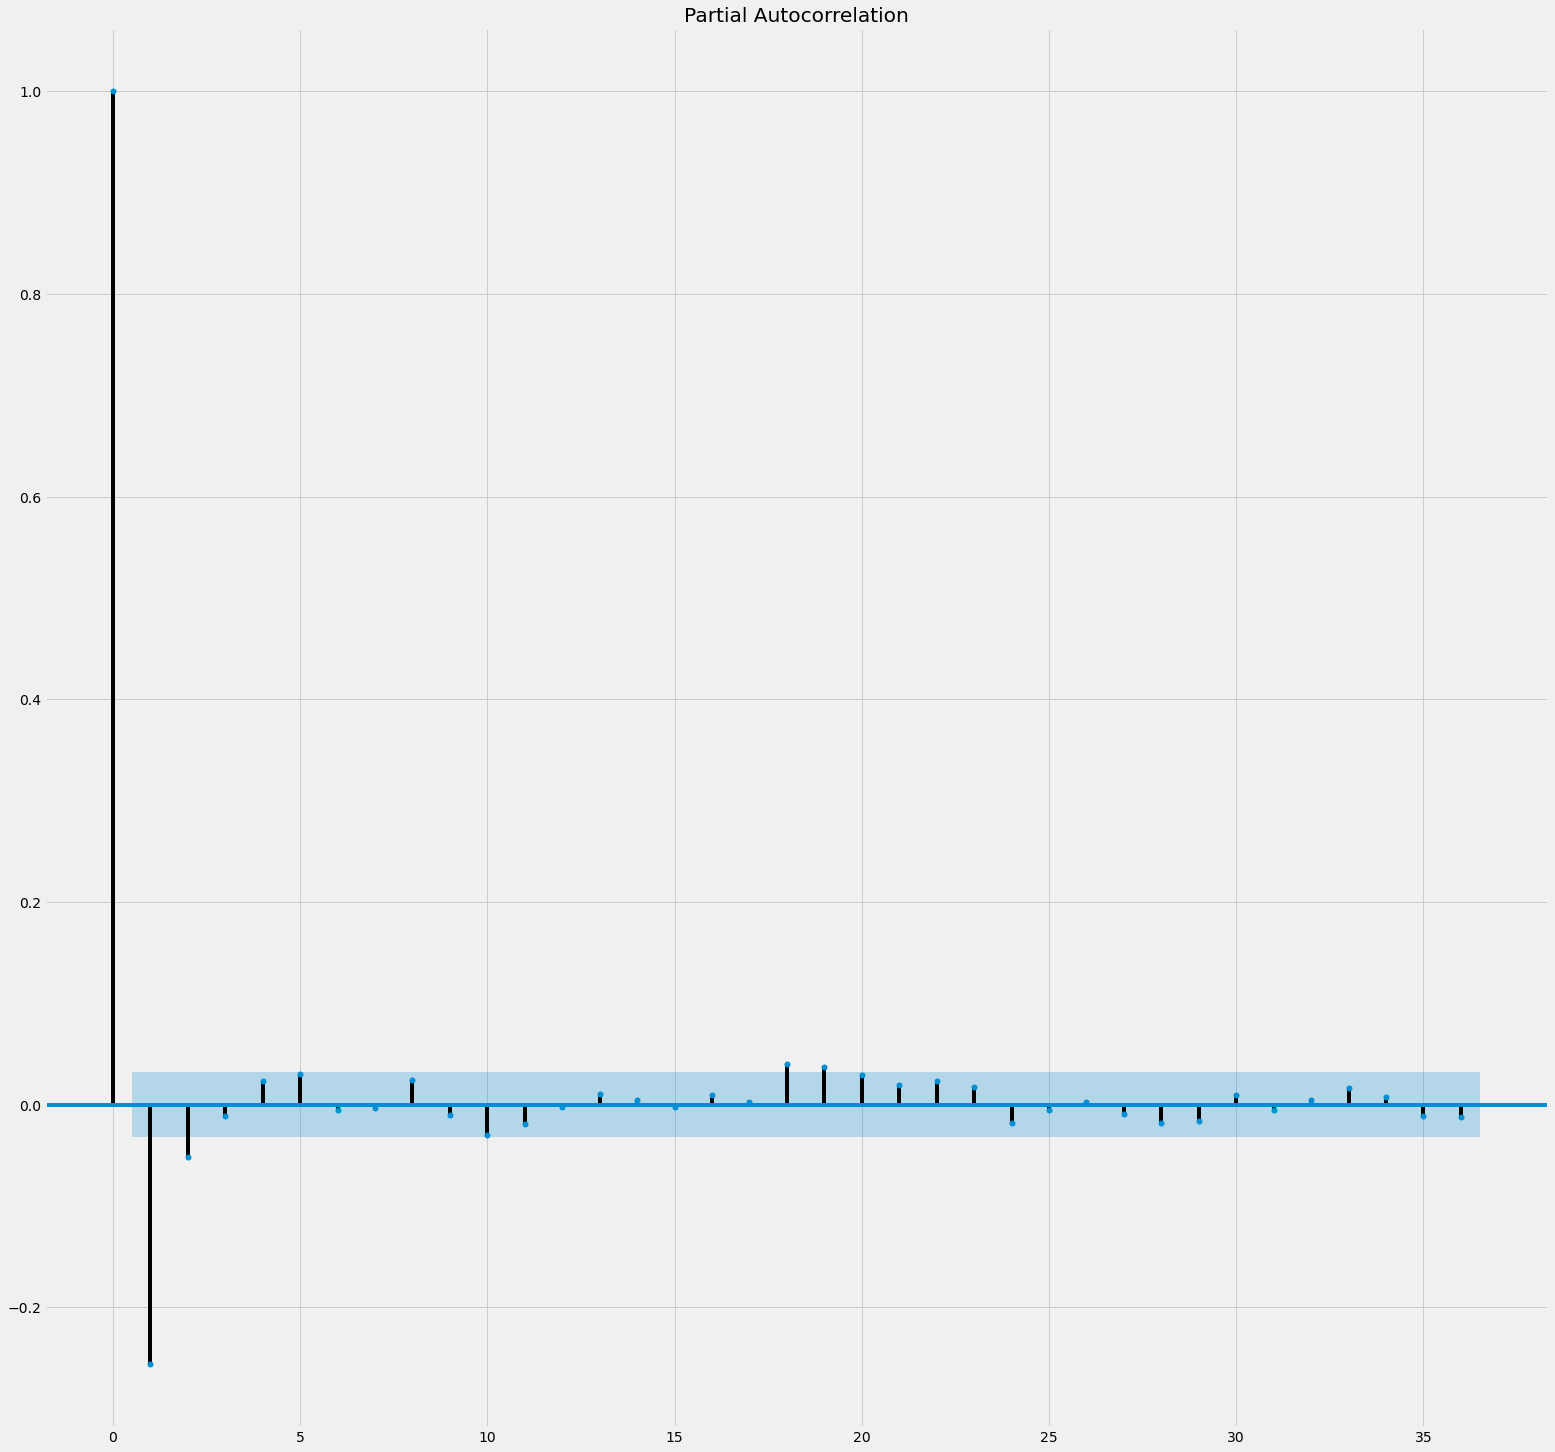

In [ ]:
fig_pacp=plot_pacf(dft["First_order_Difference"].dropna())
fig_pacp.set_size_inches(24,24)

In [ ]:
#TO call seasonal arima model 
model=sm.tsa.statespace.SARIMAX(dft["Close"],order=(0,1,0),seasonal_order=(1,1,1,20))

/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/base/tsa_model.py:219: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)


In [ ]:
arima_model=model.fit()

In [ ]:
print(arima_model.summary())

                                 Statespace Model Results                                 
Dep. Variable:                              Close   No. Observations:                 3676
Model:             SARIMAX(0, 1, 0)x(1, 1, 1, 20)   Log Likelihood              -11616.397
Date:                            Mon, 16 Nov 2020   AIC                          23238.793
Time:                                    13:16:18   BIC                          23257.405
Sample:                                         0   HQIC                         23245.421
                                           - 3676                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L20       0.0148      0.015      0.978      0.328      -0.015       0.044
ma.S.L20      -0.9995      0.090   

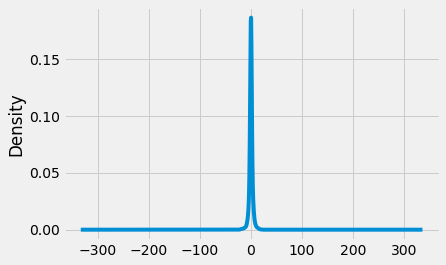

In [ ]:
arima_model.resid.plot(kind="kde")

In [ ]:
dft.shape

(3676, 12)

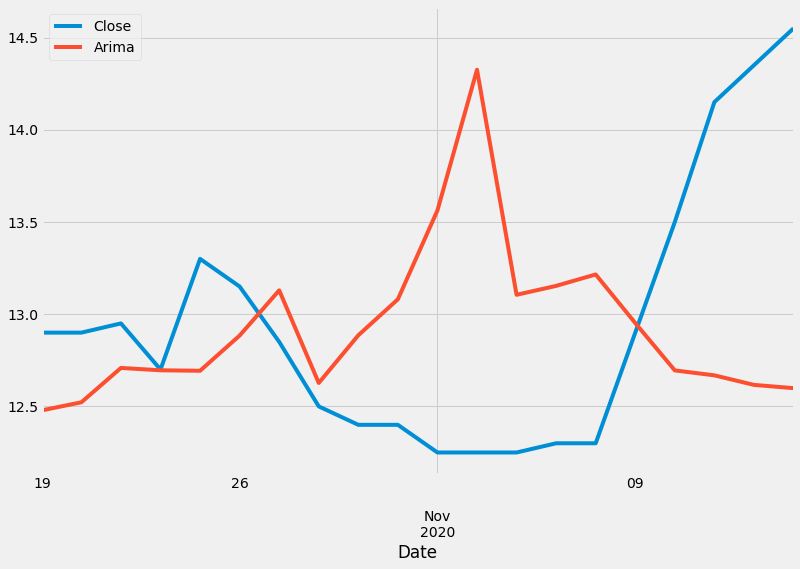

In [ ]:
End=len(dft)-1
Start=End-20
valid1["Arima"] = arima_model.predict(start =Start, end=End, dynamic= True)  
valid1[['Close','Arima']].plot(figsize=(12,8))

In [ ]:
valid1

,Close,Predictions_tree,Predictions_linear,Predictions_svr,Predictions_xg,Predictions_forrest,SMA,EWMA,Arima
Date,,,,,,,,,
2020-10-19,12.90,12.9000,15.625784,20.977007,15.470116,13.725125,13.1325,13.220197,12.478389
2020-10-20,12.90,14.3300,15.183936,20.813435,15.470116,14.680017,13.1000,13.189702,12.522244
2020-10-21,12.95,12.9500,14.840276,20.690092,15.267293,12.763857,13.0875,13.166874,12.708570
2020-10-22,12.70,12.4125,14.791182,20.672750,15.267293,12.430375,13.0650,13.122409,12.695740
2020-10-23,13.30,13.4000,14.594805,20.604077,15.267293,13.558429,13.0825,13.139323,12.693232
2020-10-26,13.15,13.1500,14.987559,20.742537,15.267293,13.564213,13.0725,13.140340,12.884134
2020-10-27,12.85,14.3300,15.183936,20.813435,15.470116,14.680017,13.0375,13.112688,13.129268
2020-10-28,12.50,13.1500,14.987559,20.742537,15.267293,13.564213,12.9950,13.054337,12.626897
2020-10-29,12.40,12.4125,14.791182,20.672750,15.267293,12.430375,12.9575,12.992019,12.885648


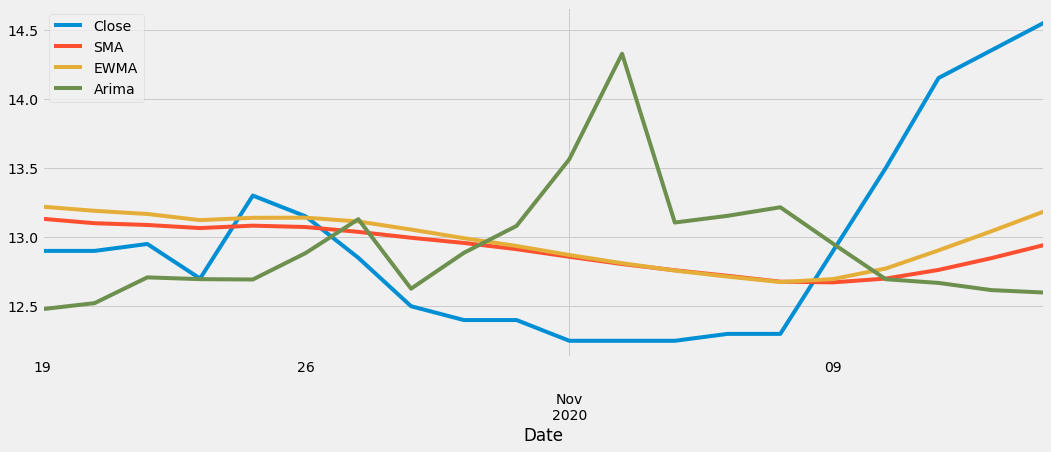

In [ ]:
valid1[["Close","SMA","EWMA","Arima"]].plot(figsize=(16,6))

# Deep Learning

## ANN(Artificial Neural Network)

### importing Tensorflow and Keras


In [ ]:
import tensorflow
print(tensorflow.__version__)
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.
keras.__version__

2.3.0


'2.4.3'

### Sequential model

In [ ]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_9 (Dense)              (None, 20)                40        
_________________________________________________________________
dense_10 (Dense)             (None, 10)                210       
_________________________________________________________________
dense_11 (Dense)             (None, 1)                 11        
Total params: 261
Trainable params: 261
Non-trainable params: 0
_________________________________________________________________


In [141]:
model = Sequential()
#First Layer
model.add(Dense(80, input_dim=1, activation='relu',kernel_initializer='RandomNormal'))
#Second layer
model.add(Dense(40, activation='relu'))
#Thrid layer
model.add(Dense(20, activation='relu'))
#Forth Layer
model.add(Dense(1))
#complile th layers
model.compile(loss='mean_squared_error', optimizer='adam')
#model.fitting
Ann=model.fit(x_train,y_train,validation_split=0.20, batch_size = 15, epochs = 1000)

Epoch 1/1000
147/147 [==============================] - 0s 3ms/step - loss: 4442.6831 - val_loss: 426.5093
Epoch 2/1000
147/147 [==============================] - 0s 2ms/step - loss: 368.4446 - val_loss: 430.2479
Epoch 3/1000
147/147 [==============================] - 0s 2ms/step - loss: 364.9050 - val_loss: 426.8064
Epoch 4/1000
147/147 [==============================] - 0s 2ms/step - loss: 377.6325 - val_loss: 434.4309
Epoch 5/1000
147/147 [==============================] - 0s 2ms/step - loss: 371.9015 - val_loss: 426.4023
Epoch 6/1000
147/147 [==============================] - 0s 2ms/step - loss: 385.4287 - val_loss: 448.3973
Epoch 7/1000
147/147 [==============================] - 0s 2ms/step - loss: 371.2627 - val_loss: 433.1371
Epoch 8/1000
147/147 [==============================] - 0s 2ms/step - loss: 373.5648 - val_loss: 468.7065
Epoch 9/1000
147/147 [==============================] - 0s 2ms/step - loss: 390.5566 - val_loss: 429.7504
Epoch 10/1000
147/147 [======================

In [142]:
ann_pred=model.predict(x_future)
valid1['ANN']=ann_pred
valid1

,Close,Predictions_tree,Predictions_linear,Predictions_svr,Predictions_xg,Predictions_forrest,SMA,EWMA,Arima,ANN
Date,,,,,,,,,,
2020-10-19,12.90,12.9000,15.625784,20.977007,15.470116,13.725125,13.1325,13.220197,12.478389,14.273314
2020-10-20,12.90,14.3300,15.183936,20.813435,15.470116,14.680017,13.1000,13.189702,12.522244,13.789738
2020-10-21,12.95,12.9500,14.840276,20.690092,15.267293,12.763857,13.0875,13.166874,12.708570,13.419297
2020-10-22,12.70,12.4125,14.791182,20.672750,15.267293,12.430375,13.0650,13.122409,12.695740,13.384406
2020-10-23,13.30,13.4000,14.594805,20.604077,15.267293,13.558429,13.0825,13.139323,12.693232,13.394941
2020-10-26,13.15,13.1500,14.987559,20.742537,15.267293,13.564213,13.0725,13.140340,12.884134,13.574813
2020-10-27,12.85,14.3300,15.183936,20.813435,15.470116,14.680017,13.0375,13.112688,13.129268,13.789738
2020-10-28,12.50,13.1500,14.987559,20.742537,15.267293,13.564213,12.9950,13.054337,12.626897,13.574813
2020-10-29,12.40,12.4125,14.791182,20.672750,15.267293,12.430375,12.9575,12.992019,12.885648,13.384406


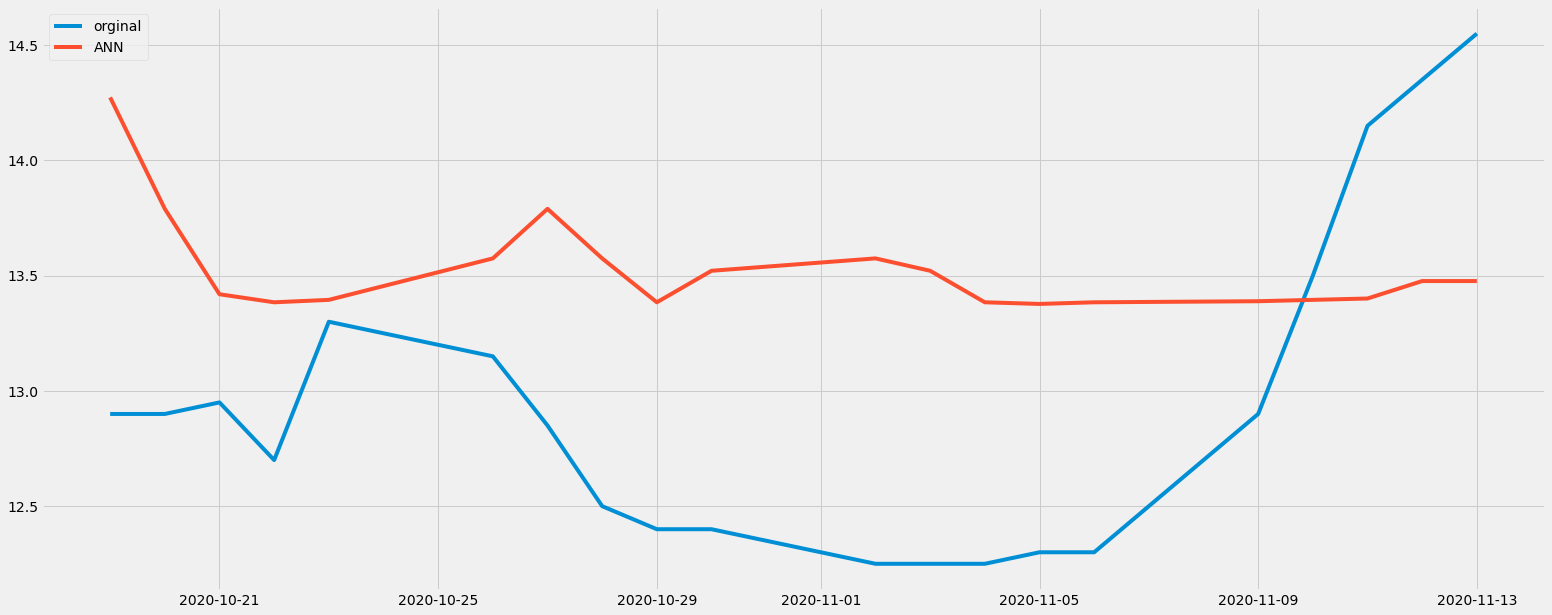

In [143]:
plt.figure(figsize=(24,10))
plt.plot(valid1[["Close","ANN"]])
plt.legend(["orginal","ANN"])
plt.show()